In [20]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg

import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, hilbert
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr


import powerlaw
import warnings
from scipy.optimize import OptimizeWarning

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

In [22]:
def avalanchesresult(session, FR=None, bin_size=0.05, neurons=None, tmax=50, threshold=30, smoothed=False, window=5):#neurons = nombre de neurones à prendre en compte, tmax = durée max à prendre en compte, threshold = seuil pour définir les avalanches, smoothed = si on veut afficher la courbe lissée, window = taille de la fenêtre pour le lissage 
    
    spikes_indiv = fma.data.loadSpikeTimes(session)
    if neurons is not None:
        spikes_indiv = dict(list(spikes_indiv.items())[:neurons])
    spikes_indiv = {key: fma.general.restrict(spikes_indiv[key], [0, tmax]) for key in spikes_indiv} 
    


    spikes = fma.data.loadSpikeTimes(session, output='compact')
    if neurons is not None:
        ind = spikes[:,1] < neurons
        spikes = spikes[ind,:]
    spikes = spikes[(spikes[:,0] >= 0) & (spikes[:,0] <= tmax),:]
    if FR is None:
        FR = fma.analysis.firingRate(spikes[:,0], bin_size=bin_size)
    time = FR[:, 0]
    rates = FR[:, 1]
    if smoothed:
        smoothed_rates = np.convolve(rates, np.ones(window)/window, mode='same')
    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates,
        threshold=threshold,
        time_step=FR[1,0] - FR[0,0],
        t0=FR[0,0]
    )

    return spikes, FR, size, intervals, size_t

In [23]:
def Generalavalanchesplot(session=None, spikes=None, FR=None, bin_size=0.05, neurons=None, tmax=50, threshold=30, smoothed=False, window=5, time_step=None):#neurons = nombre de neurones à prendre en compte, tmax = durée max à prendre en compte, threshold = seuil pour définir les avalanches, smoothed = si on veut afficher la courbe lissée, window = taille de la fenêtre pour le lissage 
    
    if spikes is None and session is None:
        return "Please provide either a session or spike times."
    if session is not None and spikes is None:
        spikes_indiv = fma.data.loadSpikeTimes(session)
    if spikes is not None:
        spikes_indiv = {}
        d = {}
        for value, neuron in spikes:
            neuron = np.uint(neuron)
            if neuron not in d:
                d[neuron] = []
            d[neuron].append(value)
        for neuron, values in d.items():
            spikes_indiv[neuron] = values
    if neurons is not None:
        spikes_indiv = dict(list(spikes_indiv.items())[:neurons])
    spikes_indiv = {key: fma.general.restrict(spikes_indiv[key], [0, tmax]) for key in spikes_indiv} 
    


    if spikes is None:
        spikes = fma.data.loadSpikeTimes(session, output='compact')
    spikes_tot = spikes
    if neurons is not None:
        ind = spikes[:,1] < neurons
        spikes = spikes[ind,:]
    spikes = spikes[(spikes[:,0] >= 0) & (spikes[:,0] <= tmax),:]
    if FR is None:
        FR = fma.analysis.firingRate(spikes_tot, bin_size=bin_size)
    FR_tot = FR
    FR = FR[FR[:,0] <= tmax,:]
    time = FR[:, 0]
    rates = FR[:, 1]
    rates_tot = FR_tot[:, 1] 
    if smoothed:
        smoothed_rates = np.convolve(rates, np.ones(window)/window, mode='same')
    if time_step is None:
        time_step=FR[1,0] - FR[0,0]

    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates_tot,
        threshold=threshold,
        time_step=time_step,
        t0=FR[0,0]
    )

    intervals = intervals[intervals[:,1]<=tmax] 
    

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,10), sharex=True)

    for n, (neuron_id, spike_times) in enumerate(spikes_indiv.items()):
    # transforme la liste en array si nécessaire
        spike_times = np.array(spike_times)
    
    # y = n pour ce neurone
        ax1.scatter(spike_times, 
                [neuron_id] * len(spike_times), 
                marker='|', 
                s=100,     # taille du trait
                color='black')
    
    for t1, t2 in intervals:
        ax1.axvspan(t1, t2, color='red', alpha=0.3)


    ax2.plot(time[:len(rates)] , rates, color='green', label='Firing rate')
    if smoothed:
        ax2.plot(time[:len(smoothed_rates)], smoothed_rates, color='blue', label='Smoothed firing rate')
    for t1, t2 in intervals:
        ax2.axvspan(t1, t2, color='red', alpha=0.3)

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Neuron Index")
    ax1.set_title("Spikes with avalanches")

    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Firing rate (Hz)")
    ax2.set_title("Firing rate (moving average) with avalanches")
    ax2.legend()

    
    plt.show()


In [24]:
"""
Pipeline de sélection optimale (bin_size, threshold)
pour l'analyse des avalanches neuronales — Nucleus Reuniens

Étapes :
  1. Grille bin_sizes : 2–50 ms (pas 2ms) + IEI, IEI/2, 88, 187, 250 ms
  2. Grille thresholds : [0, 30, 50, 75] percentile
  3. Pour chaque threshold : 3 graphiques (variance, tau, R/p)
  4. Sélection des couples (threshold, bin_size) valides
  5. Pour chaque bin_size valide : avalanche rate vs threshold (0–80%)
  6. Robustesse tau sur ±3 bins voisins autour du bin_size optimal
"""

# ════════════════════════════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════════════════════════════

def _estimate_iei(spikes, tmax):
    """IEI moyen de la population = 1 / FR_totale."""
    neurons = np.unique(spikes[:, 1])
    total_rate = 0.0
    for n in neurons:
        t = spikes[spikes[:, 1] == n, 0]
        t = t[(t >= 0) & (t <= tmax)]
        if len(t) > 1:
            total_rate += len(t) / tmax
    if total_rate == 0:
        return 0.010  # fallback 10 ms
    iei = 1.0 / total_rate
    print(f"  FR totale population : {total_rate:.1f} Hz")
    print(f"  IEI population       : {iei * 1000:.3f} ms")
    return iei


def _shuffle_spikes(spikes, tmax):
    """Permute les ISI de chaque neurone — détruit les corrélations inter-neurones."""
    neurons = np.unique(spikes[:, 1])
    out = []
    for n in neurons:
        t = np.sort(spikes[spikes[:, 1] == n, 0])
        if len(t) < 2:
            continue
        isis = np.diff(t)
        np.random.shuffle(isis)
        t_sh = np.concatenate([[np.random.uniform(0, 0.1)], np.cumsum(isis)])
        t_sh = t_sh[t_sh <= tmax]
        out.append(np.column_stack([t_sh, np.full(len(t_sh), n)]))
    return np.vstack(out) if out else spikes


def _powerlaw_fit(data):
    """
    Fit power law via Clauset et al. 2007.
    Retourne (tau, sigma, xmin, xmax_fit, R_vs_exp, p_vs_exp) ou nans.
    """
    data = np.asarray(data, dtype=float)
    data = data[data >= 1]

    if len(np.unique(data)) < 2 or len(data) < 20:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    
    # Caster en int explicitement avant le fit → supprime le warning discret
    data_int = data.astype(int)
    data_int = data_int[data_int >= 1]

        # Guard : pas assez de valeurs distinctes pour un fit fiable
    unique_vals = np.unique(data_int)
    if len(unique_vals) < 4:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    # Guard : si 90%+ des valeurs sont identiques → distribution trop dégénérée
    most_common_freq = np.max(np.bincount(data_int)) / len(data_int)
    if most_common_freq > 0.90:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan


    with warnings.catch_warnings():
        #warnings.simplefilter("ignore")
        warnings.simplefilter("ignore", OptimizeWarning)
        warnings.simplefilter("ignore", UserWarning)
        try:
            fit = powerlaw.Fit(data_int, discrete=True, verbose=False)
        except (ValueError, RuntimeWarning):
            return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    tau   = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin  = fit.xmin
    xmax  = fit.xmax if fit.xmax is not None else np.max(data_int)
    n_tail_proportion = fit.n_tail / len(data)

    if np.isnan(tau):
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        R, p = fit.distribution_compare('power_law', 'exponential',
                                        normalized_ratio=True)
    return tau, sigma, xmin, xmax, R, p, n_tail_proportion


def _detect_avalanches(FR, threshold_pct, bin_size):
    """Détecte les avalanches depuis une FR (array Nx2)."""
    rates = FR[:, 1]
    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates,
        threshold=threshold_pct,
        time_step=bin_size,
        t0=FR[0, 0]
    )
    return size, intervals, size_t, rates


def _avalanche_rate(intervals, rates, bin_size):
    """
    Avalanche rate = nombre de bins actifs / durée totale.
    Un bin actif = appartient à une avalanche.
    """
    #tmax = len(rates) * bin_size
    tmax = intervals[-1][1]
    n_active_bins = 0
    for t1, t2 in intervals:
        n_active_bins += max(1, round((t2 - t1) / bin_size))
    return n_active_bins / tmax if tmax > 0 else 0.0


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 1+2 : CALCUL DE TOUTES LES MÉTRIQUES
# ════════════════════════════════════════════════════════════════════════════

def compute_grid(session, spikes, FR_cache,
                 bin_sizes, thresholds,
                 tmax, n_shuffles=20):
    """
    Pour chaque (bin_size, threshold) :
      - variance des tailles d'avalanches
      - tau, sigma, xmin, xmax_fit, R, p  (données réelles)
      - tau_shuffle (moyenne ± std sur n_shuffles)
      - avalanche_rate

    FR_cache : dict {bin_size: FR_array} — évite de recalculer les FR

    Retourne results[threshold][bin_size] = dict de métriques
    """
    results = {thr: {} for thr in thresholds}

    R = rg.data.Regions(session, ids=["nr"], states=['sws', 'rem'])

    for bs in bin_sizes:
        bs_ms = bs * 1000
        print(f"\n── bin={bs_ms:.2f} ms ──")

        # FR population (depuis cache ou calcul)
        if bs not in FR_cache:
            FR_cache[bs] = R.firingRate(regs=["nr"], states='sws', window=bs, step=1, shift=True)
        FR = FR_cache[bs]

        for thr in thresholds:
            size, intervals, size_t, rates = _detect_avalanches(FR, thr, bs)
            sizes = size[size > 0]

            # Variance des tailles
            var_size = np.var(sizes) if len(sizes) > 1 else np.nan

            # Fit power law
            tau, sigma, xmin, xmax_fit, R, p, n_tail_proportion = _powerlaw_fit(sizes)

            # Plage de fit
            fit_range = (xmax_fit/xmin) if (not np.isnan(xmin) and
                                               not np.isnan(xmax_fit)) else np.nan

            # Après : tau, sigma, xmin, xmax_fit, R, p = _powerlaw_fit(sizes)

# Fit power law sur les durées
            durations = (intervals[:, 1] - intervals[:, 0])/bs#NORMALISATION PAR BIN SIZE POUR AVOIR DES DUREES EN NOMBRE DE BINS !!!!!!! 
            durations = durations[durations > 0]
            tau_dur, sigma_dur, xmin_dur, xmax_dur, R_dur, p_dur, n_tail_proportion_dur = _powerlaw_fit(durations)
            fit_range_dur = (xmax_dur / xmin_dur) if (not np.isnan(xmin_dur) and
                                           not np.isnan(xmax_dur)) else np.nan

# Relation de scaling <taille>(T) → tau_gamma
            tau_gamma = np.nan
            if len(intervals) > 10 and len(sizes) == len(durations):
                unique_durs = np.unique(durations)
                mean_sizes_T = []
                valid_durs   = []
                for d in unique_durs:
                    mask = np.abs(durations - d) < bs * 0.5
                    if mask.sum() >= 5:
                        mean_sizes_T.append(sizes[mask].mean())
                        valid_durs.append(d)
                if len(valid_durs) >= 5:
                    log_d = np.log10(np.array(valid_durs))
                    log_s = np.log10(np.array(mean_sizes_T))
                    valid = np.isfinite(log_d) & np.isfinite(log_s)
                    if valid.sum() >= 3:
                        tau_gamma = np.polyfit(log_d[valid], log_s[valid], 1)[0]

# Ratio des exposants
            ratio_exp = ((tau_dur - 1) / (tau - 1)
                         
            if not np.isnan(tau_dur) and not np.isnan(tau) and (tau - 1) != 0
            else np.nan)

            # Avalanche rate
            aval_rate = _avalanche_rate(intervals, rates, bs)

            # Shuffle control
            tau_sh_list = []
            R_sh_list = []
            p_sh_list = []
            for _ in range(n_shuffles):
                sp_sh  = _shuffle_spikes(spikes, tmax)
                FR_sh  = fma.analysis.firingRate(sp_sh[:, 0], bin_size=bs)
                sz_sh, _, _, _ = _detect_avalanches(FR_sh, thr, bs)
                t_sh, sigma_sh, xmin_sh, xmax_sh, R_sh, p_sh, n_tail_proportion_sh = _powerlaw_fit(sz_sh[sz_sh > 0])
                if not np.isnan(t_sh):
                    tau_sh_list.append(t_sh)
                if not np.isnan(R_sh):
                    R_sh_list.append(R_sh)
                if not np.isnan(p_sh):
                    p_sh_list.append(p_sh)
            R_sh_mean = np.mean(R_sh_list) if R_sh_list else np.nan
            R_sh_std  = np.std(R_sh_list)  if R_sh_list else np.nan
            p_sh_mean = np.mean(p_sh_list) if p_sh_list else np.nan
            p_sh_std  = np.std(p_sh_list)  if p_sh_list else np.nan
            tau_sh_mean = np.mean(tau_sh_list) if tau_sh_list else np.nan
            tau_sh_std  = np.std(tau_sh_list)  if tau_sh_list else np.nan

            results[thr][bs] = dict(
                var_size=var_size,
                tau=tau, sigma=sigma,
                xmin=xmin, xmax_fit=xmax_fit, fit_range=fit_range,
                R=R, p=p, n_tail_proportion=n_tail_proportion,
                R_sh_mean = R_sh_mean, R_sh_std = R_sh_std,
                p_sh_mean = p_sh_mean, p_sh_std = p_sh_std,
                tau_sh_mean=tau_sh_mean, tau_sh_std=tau_sh_std,
                aval_rate=aval_rate,
                n_aval=len(sizes),
                tau_dur=tau_dur, sigma_dur=sigma_dur,
            xmin_dur=xmin_dur, xmax_dur=xmax_dur,
            fit_range_dur=fit_range_dur,
            n_tail_proportion_dur=n_tail_proportion_dur,
            tau_gamma=tau_gamma,
            ratio_exp=ratio_exp,
            )
            print(f"  thr={thr:2d}% | N={len(sizes):6d} | "
                  f"τ={tau:.3f} | τ_sh={tau_sh_mean:.3f}±{tau_sh_std:.3f} | "
                  f"R={R:.2f} p={p:.3f} | aval_rate={aval_rate:.4f}| n_tail_prop={n_tail_proportion:.3f} | tau_dur={tau_dur:.3f} | tau_gamma={tau_gamma:.3f} | ratio_exp={ratio_exp:.3f}")

    return results


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : GRAPHIQUES PAR THRESHOLD
# ════════════════════════════════════════════════════════════════════════════

# Remplacer les nan par des valeurs neutres pour l'affichage
def _safe_log_arr(arr):
        """Remplace les nan/<=0 par nan (déjà le cas), 
        mais garantit qu'il reste au moins un point positif."""
        a = np.array(arr, dtype=float)
        a[a <= 0] = np.nan
        return a
    
def plot_metrics_per_threshold(results, bin_sizes, thresholds):
    figs = []
    for thr in thresholds:
        bs_ms       = np.array([bs * 1000 for bs in bin_sizes])
        r           = results[thr]
 
        tau         = np.array([r[bs]['tau']          for bs in bin_sizes])
        tau_sh      = np.array([r[bs]['tau_sh_mean']  for bs in bin_sizes])
        tau_std     = np.array([r[bs]['tau_sh_std']   for bs in bin_sizes])
        tau_dur     = np.array([r[bs]['tau_dur']      for bs in bin_sizes])
        R_arr       = np.array([r[bs]['R']            for bs in bin_sizes])
        p_arr       = np.array([r[bs]['p']            for bs in bin_sizes])
        R_sh_m      = np.array([r[bs]['R_sh_mean']    for bs in bin_sizes])
        R_sh_s      = np.array([r[bs]['R_sh_std']     for bs in bin_sizes])
        p_sh_m      = np.array([r[bs]['p_sh_mean']    for bs in bin_sizes])
        p_sh_s      = np.array([r[bs]['p_sh_std']     for bs in bin_sizes])
        ratio_exp   = np.array([r[bs]['ratio_exp']    for bs in bin_sizes])
        tau_gamma   = np.array([r[bs]['tau_gamma']    for bs in bin_sizes])
        n_tail_prop = np.array([r[bs]['n_tail_proportion'] for bs in bin_sizes])
        n_tail_prop_dur = np.array([r[bs]['n_tail_proportion_dur'] for bs in bin_sizes])
        fit_rng     = _safe_log_arr([r[bs]['fit_range']     for bs in bin_sizes])
        fit_rng_dur = _safe_log_arr([r[bs]['fit_range_dur'] for bs in bin_sizes])
 
        # Limites x pour forcer le xlim sur tous les axes (évite crash log scale)
        bs_pos  = bs_ms[bs_ms > 0]
        bs_lim  = (bs_pos.min(), bs_pos.max()) if len(bs_pos) >= 2 else (1, 1000)
 
        fig, axes = plt.subplots(1, 4, figsize=(24, 5))
        fig.suptitle(f'Threshold = {thr}e percentile', fontsize=13, y=1.01)
 
        # ── Plot 1 : τ_size vs bin_size ──────────────────────────────────────
        ax = axes[0]
        ax.axhline(1.5, color='grey', lw=1, ls='--', label='τ théorique = 1.5')
        valid_sh = ~np.isnan(tau_sh) & ~np.isnan(tau_std)
        ax.fill_between(bs_ms[valid_sh],
                        (tau_sh - 2*tau_std)[valid_sh],
                        (tau_sh + 2*tau_std)[valid_sh],
                        alpha=0.2, color='tomato', label='Shuffle ±2σ')
        ax.plot(bs_ms[valid_sh], tau_sh[valid_sh],
                color='tomato', ls='--', lw=1)
        valid_tau = ~np.isnan(tau)
        ax.plot(bs_ms[valid_tau], tau[valid_tau],
                'o-', color='steelblue', lw=2, label='τ_size')
        ax.set_xscale('log')
        ax.set_xlim(bs_lim)
        ax2 = ax.twinx()
        ax2.set_xlim(bs_lim)
        valid_rng = ~np.isnan(fit_rng)
        if valid_rng.sum() > 0:
            ax2.plot(bs_ms[valid_rng], fit_rng[valid_rng],
                     's--', color='purple', lw=1, alpha=0.7, label='xmax/xmin (size)')
            ax2.set_ylabel('xmax/xmin', color='purple')
            ax2.tick_params(axis='y', labelcolor='purple')
        ax.set_xlabel('Bin size (ms)')
        ax.set_ylabel('τ_size')
        ax.set_title('τ size vs bin_size')
        lines1, l1 = ax.get_legend_handles_labels()
        lines2, l2 = ax2.get_legend_handles_labels()
        ax.legend(lines1+lines2, l1+l2, fontsize=7)
        ax.grid(True, alpha=0.3)
 
        # ── Plot 2 : τ_duration vs bin_size ─────────────────────────────────
        ax = axes[1]
        ax.axhline(2.0, color='grey', lw=1, ls='--', label='τ_dur théorique = 2.0')
        valid_td = ~np.isnan(tau_dur)
        ax.plot(bs_ms[valid_td], tau_dur[valid_td],
                'o-', color='darkorange', lw=2, label='τ_duration')
        ax.set_xscale('log')
        ax.set_xlim(bs_lim)
        ax3 = ax.twinx()
        ax3.set_xlim(bs_lim)
        valid_rd = ~np.isnan(fit_rng_dur)
        if valid_rd.sum() > 0:
            ax3.plot(bs_ms[valid_rd], fit_rng_dur[valid_rd],
                     's--', color='purple', lw=1, alpha=0.7, label='xmax/xmin (dur)')
            ax3.set_ylabel('xmax/xmin', color='purple')
            ax3.tick_params(axis='y', labelcolor='purple')
        ax.set_xlabel('Bin size (ms)')
        ax.set_ylabel('τ_duration')
        ax.set_title('τ duration vs bin_size')
        lines1, l1 = ax.get_legend_handles_labels()
        lines2, l2 = ax3.get_legend_handles_labels()
        ax.legend(lines1+lines2, l1+l2, fontsize=7)
        ax.grid(True, alpha=0.3)
 
        # ── Plot 3 : R et p vs bin_size ──────────────────────────────────────
        ax = axes[2]
        valid_Rsh = ~np.isnan(R_sh_m) & ~np.isnan(R_sh_s)
        ax.fill_between(bs_ms[valid_Rsh],
                        (R_sh_m - 2*R_sh_s)[valid_Rsh],
                        (R_sh_m + 2*R_sh_s)[valid_Rsh],
                        alpha=0.2, color='darkgreen', label='Shuffle ±2σ')
        ax.plot(bs_ms[valid_Rsh], R_sh_m[valid_Rsh],
                color='darkgreen', ls='--', lw=1)
        valid_R = ~np.isnan(R_arr)
        ax.plot(bs_ms[valid_R], R_arr[valid_R],
                'o-', color='darkgreen', lw=2, label='R')
        ax.axhline(0, color='grey', lw=1, ls='--')
        ax.set_xscale('log')
        ax.set_xlim(bs_lim)
        ax.set_xlabel('Bin size (ms)')
        ax.set_ylabel('R  (>0 = power law préférée)', color='darkgreen')
        ax.tick_params(axis='y', labelcolor='darkgreen')
        ax4 = ax.twinx()
        ax4.set_xlim(bs_lim)
        valid_psh = ~np.isnan(p_sh_m) & ~np.isnan(p_sh_s)
        if valid_psh.sum() > 0:
            ax4.fill_between(bs_ms[valid_psh],
                             (p_sh_m - 2*p_sh_s)[valid_psh],
                             (p_sh_m + 2*p_sh_s)[valid_psh],
                             alpha=0.2, color='orange')
            ax4.plot(bs_ms[valid_psh], p_sh_m[valid_psh],
                     color='orange', ls='--', lw=1)
        if valid_R.sum() > 0:
            ax4.plot(bs_ms[valid_R], p_arr[valid_R],
                     's-', color='orange', lw=1, label='p-value')
        ax4.axhline(0.05, color='orange', lw=0.8, ls=':', alpha=0.6)
        ax4.set_ylabel('p-value', color='orange')
        ax4.tick_params(axis='y', labelcolor='orange')
        ax.set_title('Power law vs Exponentielle')
        lines1, l1 = ax.get_legend_handles_labels()
        lines2, l2 = ax4.get_legend_handles_labels()
        ax.legend(lines1+lines2, l1+l2, fontsize=7)
        ax.grid(True, alpha=0.3)
 
        # ── Plot 4 : ratio (τ_dur-1)/(τ_size-1) et tau_gamma ────────────────
        ax = axes[3]
        ax.axhline(2.0, color='grey', lw=1, ls='--',
                   label='ratio théorique ≈ 2.0')
        valid_ratio = ~np.isnan(ratio_exp)
        ax.plot(bs_ms[valid_ratio], ratio_exp[valid_ratio],
                'o-', color='steelblue', lw=2, label='(τ_dur-1)/(τ_size-1)')
        ax.set_xscale('log')
        ax.set_xlim(bs_lim)
        ax.set_xlabel('Bin size (ms)')
        ax.set_ylabel('(τ_dur-1)/(τ_size-1)', color='steelblue')
        ax.tick_params(axis='y', labelcolor='steelblue')
        ax5 = ax.twinx()
        ax5.set_xlim(bs_lim)
        valid_tg = ~np.isnan(tau_gamma)
        if valid_tg.sum() > 0:
            ax5.plot(bs_ms[valid_tg], tau_gamma[valid_tg],
                     's--', color='crimson', lw=1.5, label='τ_gamma (scaling)')
            ax5.axhline(2.0, color='crimson', lw=0.8, ls=':', alpha=0.5)
            ax5.set_ylabel('τ_gamma', color='crimson')
            ax5.tick_params(axis='y', labelcolor='crimson')
        ax.set_title('Relation de scaling')
        lines1, l1 = ax.get_legend_handles_labels()
        lines2, l2 = ax5.get_legend_handles_labels()
        ax.legend(lines1+lines2, l1+l2, fontsize=7)
        ax.grid(True, alpha=0.3)
 
        plt.tight_layout()
        plt.show()
        figs.append(fig)
 
    return figs
 



# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 : SÉLECTION DES COUPLES VALIDES
# ════════════════════════════════════════════════════════════════════════════

def select_valid_pairs(results, bin_sizes, thresholds, max_pairs=15):
    """
    Critères de sélection :
      τ > τ_shuffle  ET  R > 0  ET  p < 0.05

    Si > max_pairs couples valides : garde les max_pairs avec bin_size le plus faible.

    Retourne liste de (threshold, bin_size, métriques).
    """
    valid = []
    for thr in thresholds:
        for bs in bin_sizes:
            m = results[thr][bs]
            tau      = m['tau']
            tau_sh   = m['tau_sh_mean']
            tau_std   = m['tau_sh_std']
            R        = m['R']
            p        = m['p']
            n_tail_prop = m['n_tail_proportion']

            if any(np.isnan([tau, tau_sh, R, p])):
                continue

            if abs(tau - tau_sh) > 2*tau_std and R > 0 and p < 0.05 and n_tail_prop > 0.1:
                valid.append((thr, bs, m))

    print(f"\n{'═'*55}")
    print(f"  Couples valides (τ>τ_sh, R>0, p<0.05) : {len(valid)}")
    print(f"{'═'*55}")
    for thr, bs, m in valid:
        print(f"  thr={thr:2d}% | bin={bs*1000:.2f} ms | "
              f"τ={m['tau']:.3f} | R={m['R']:.2f} | p={m['p']:.3f}")

    if len(valid) > max_pairs:
        print(f"\n  → Plus de {max_pairs} couples : on garde les {max_pairs} "
              f"avec le plus petit bin_size.")
        valid = sorted(valid, key=lambda x: x[1])[:max_pairs]
        print(f"  Couples retenus :")
        for thr, bs, m in valid:
            print(f"    thr={thr:2d}% | bin={bs*1000:.2f} ms")

    return valid



In [26]:
# ════════════════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPALE
# ════════════════════════════════════════════════════════════════════════════


session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R       = rg.data.Regions(session, ids=["nr"], states=['sws', 'rem'])
spikes  = R.spikes(regs=["nr"], state='sws', shift=True)   # array (N, 2)
tmax    = spikes[:, 0].max()

print(f"N spikes   : {len(spikes)}")
print(f"N neurones : {len(np.unique(spikes[:, 1]))}")
print(f"tmax       : {tmax:.1f} s")

n_shuffles = 10
#max_valid_pairs = 5
thresholds = [0, 30, 50, 80]

    # ── Grille de bin_sizes ──────────────────────────────────────────────────
print("[0] Estimation IEI population…")
iei     = _estimate_iei(spikes, tmax)
iei_ms  = iei * 1000

    # 2 à 50 ms, pas de 2 ms
base_bins = np.arange(2, 52, 2) / 1000
    # Bins supplémentaires
extra_bins = np.array([iei / 2, iei, 0.087])
    # Union + tri + dédoublonnage
all_bins = np.unique(np.concatenate([base_bins, extra_bins]))
    # Garder seulement les bins > 0
all_bins = all_bins[all_bins > 0]

print(f"  Grille : {len(all_bins)} bin_sizes de "
          f"{all_bins.min()*1000:.2f} à {all_bins.max()*1000:.2f} ms")
print(f"  Dont IEI/2={iei_ms/2:.2f} ms, IEI={iei_ms:.2f} ms, "
          f"88 ms, 187 ms, 250 ms")

N spikes   : 553644
N neurones : 47
tmax       : 5808.3 s
[0] Estimation IEI population…
  FR totale population : 95.3 Hz
  IEI population       : 10.491 ms
  Grille : 28 bin_sizes de 2.00 à 87.00 ms
  Dont IEI/2=5.25 ms, IEI=10.49 ms, 88 ms, 187 ms, 250 ms


In [27]:
    # ── Calcul de toutes les métriques ───────────────────────────────────────
print(f"\n[1] Calcul métriques pour {len(all_bins)} bins × "
          f"{len(thresholds)} thresholds × {n_shuffles} shuffles…")

FR_cache = {}
for bs in all_bins:  # all_bins calculé séparément
        FR_cache[bs] = R.firingRate(regs=["nr"], states='sws', window=bs, step=1, shift=True)


[1] Calcul métriques pour 28 bins × 4 thresholds × 10 shuffles…


In [28]:
results  = compute_grid(session, spikes, FR_cache, all_bins, thresholds,
                             tmax, n_shuffles=n_shuffles)


── bin=2.00 ms ──
  thr= 0% | N=362275 | τ=2.495 | τ_sh=2.688±0.001 | R=-57.60 p=0.000 | aval_rate=87.6292| n_tail_prop=1.000 | tau_dur=2.584 | tau_gamma=1.035 | ratio_exp=1.060
  thr=30% | N=362275 | τ=2.495 | τ_sh=2.689±0.002 | R=-57.60 p=0.000 | aval_rate=87.6292| n_tail_prop=1.000 | tau_dur=2.584 | tau_gamma=1.035 | ratio_exp=1.060
  thr=50% | N=362275 | τ=2.495 | τ_sh=2.688±0.001 | R=-57.60 p=0.000 | aval_rate=87.6292| n_tail_prop=1.000 | tau_dur=2.584 | tau_gamma=1.035 | ratio_exp=1.060
  thr=80% | N=362275 | τ=2.495 | τ_sh=2.689±0.003 | R=-57.60 p=0.000 | aval_rate=87.6292| n_tail_prop=1.000 | tau_dur=2.584 | tau_gamma=1.035 | ratio_exp=1.060

── bin=4.00 ms ──
  thr= 0% | N=220648 | τ=2.756 | τ_sh=2.843±0.003 | R=-29.55 p=0.000 | aval_rate=74.9966| n_tail_prop=0.321 | tau_dur=2.664 | tau_gamma=1.077 | ratio_exp=0.948
  thr=30% | N=220648 | τ=2.756 | τ_sh=2.843±0.004 | R=-29.55 p=0.000 | aval_rate=74.9966| n_tail_prop=0.321 | tau_dur=2.664 | tau_gamma=1.077 | ratio_exp=0.948
  


[2] Graphiques par threshold…


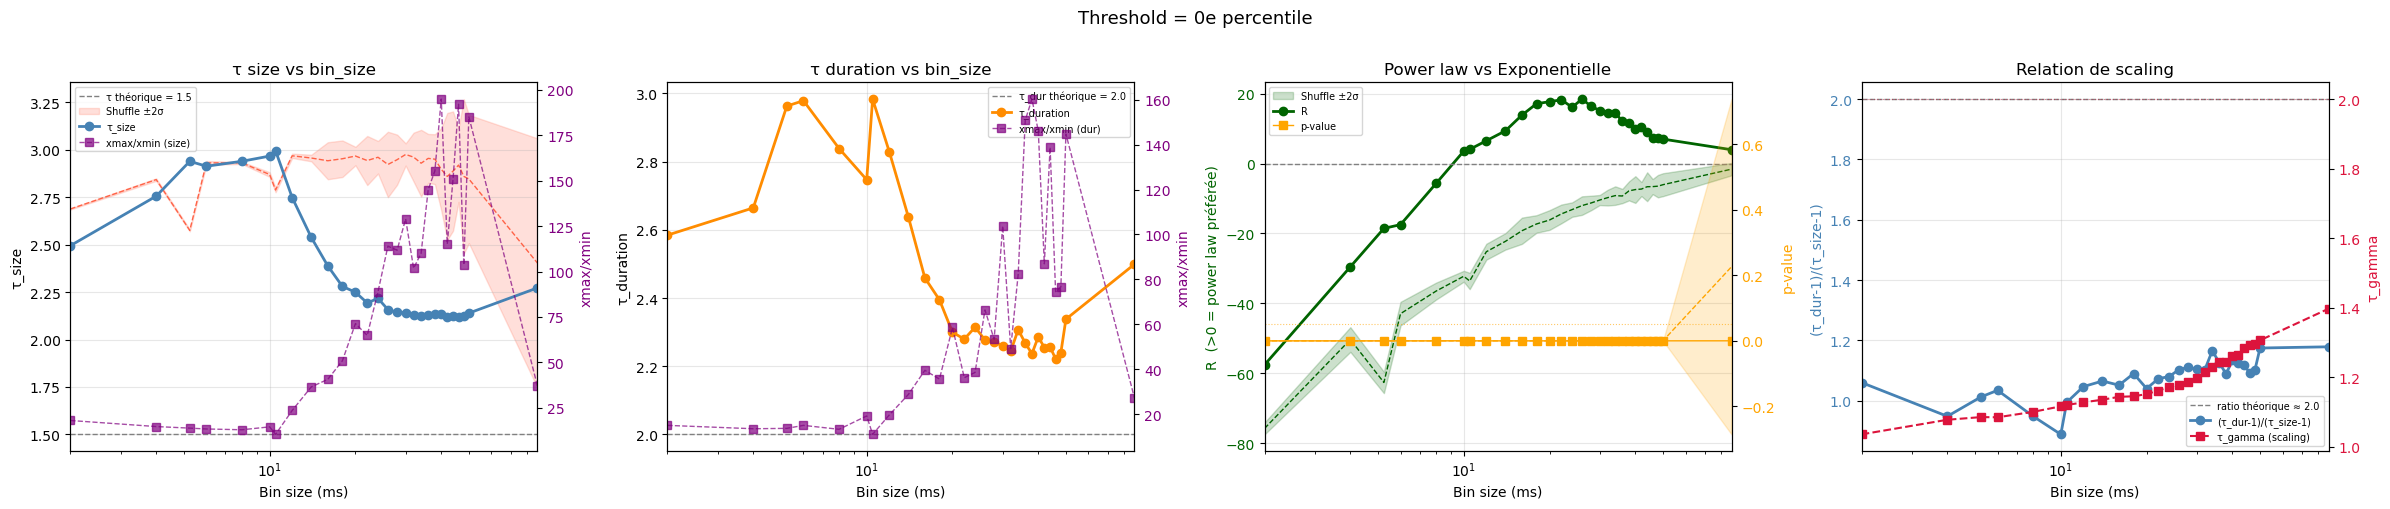

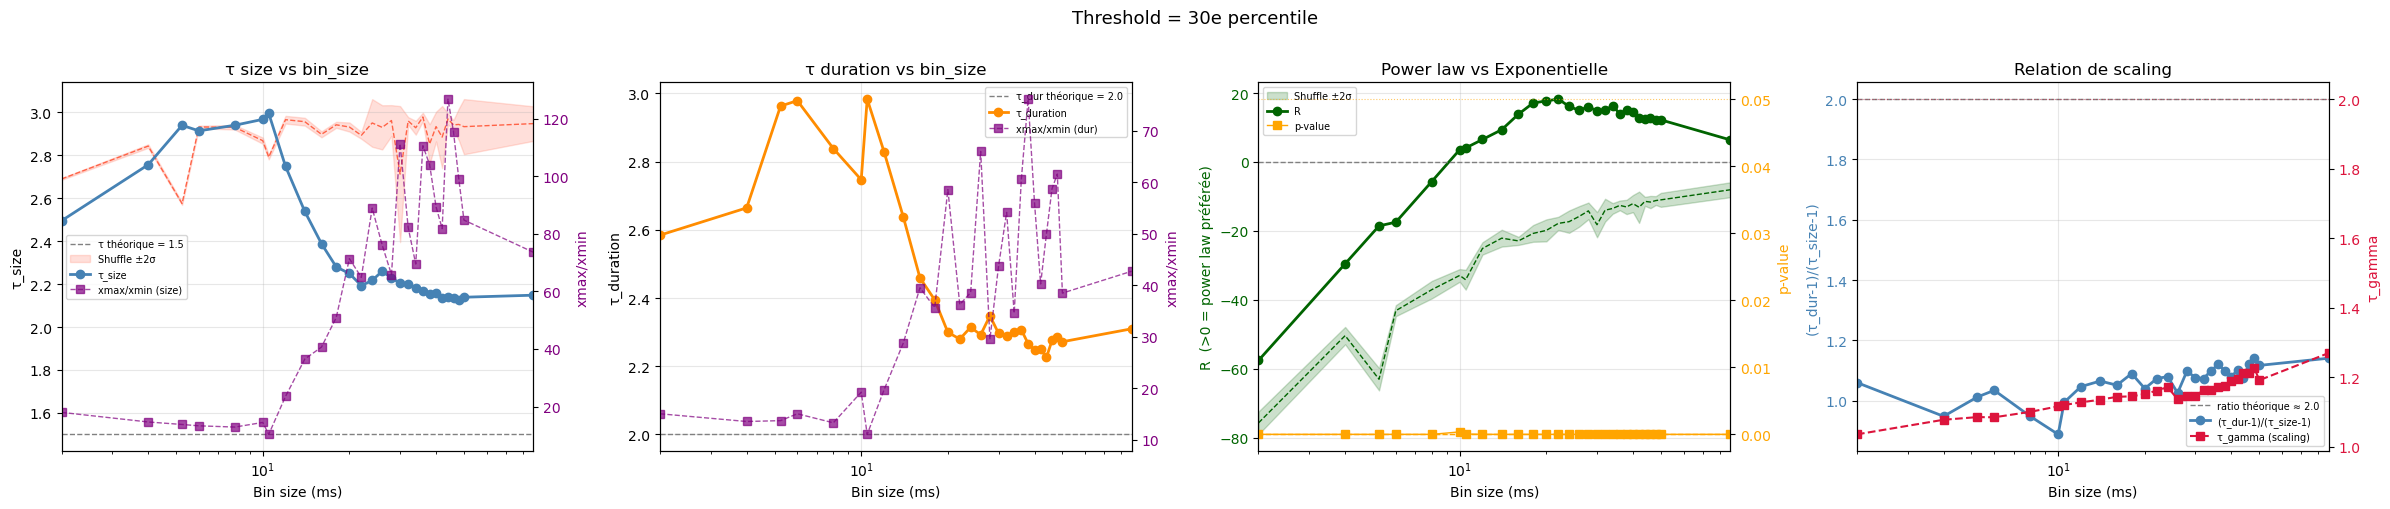

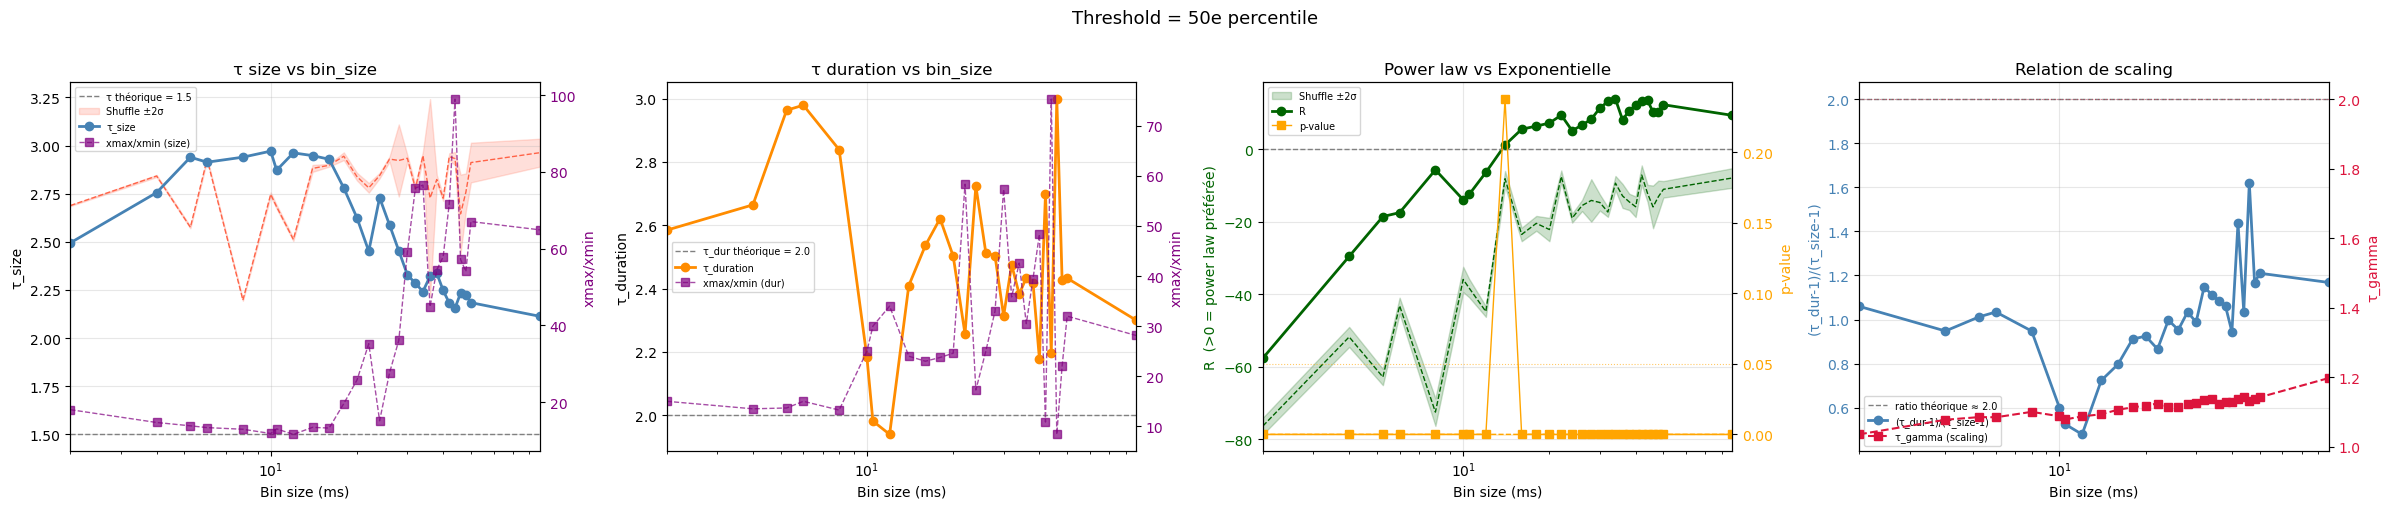

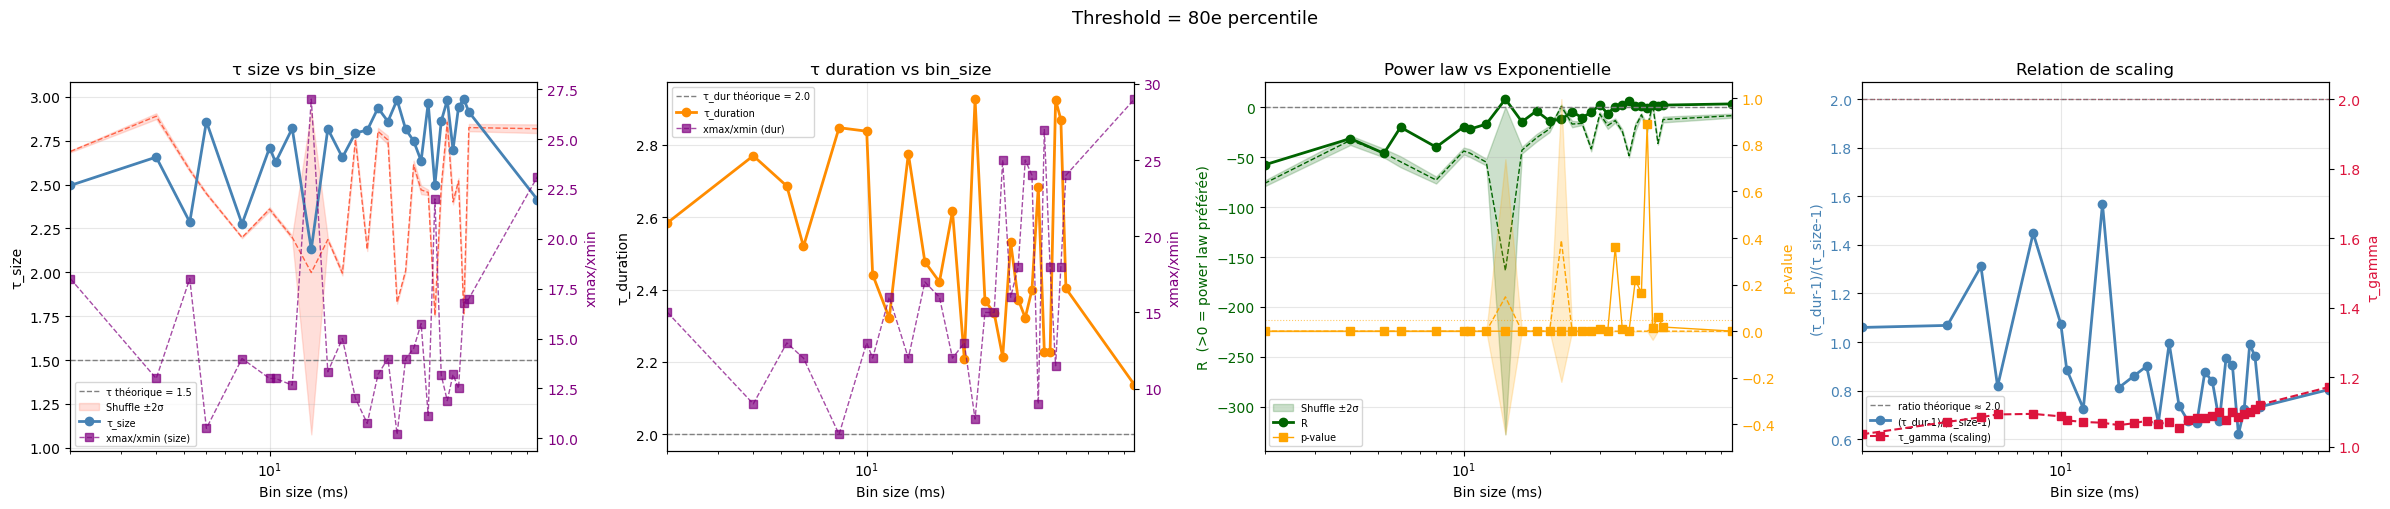


[3] Sélection des couples valides…

═══════════════════════════════════════════════════════
  Couples valides (τ>τ_sh, R>0, p<0.05) : 57
═══════════════════════════════════════════════════════
  thr= 0% | bin=16.00 ms | τ=2.388 | R=13.86 | p=0.000
  thr= 0% | bin=18.00 ms | τ=2.280 | R=17.12 | p=0.000
  thr= 0% | bin=20.00 ms | τ=2.249 | R=17.71 | p=0.000
  thr= 0% | bin=22.00 ms | τ=2.193 | R=18.24 | p=0.000
  thr= 0% | bin=24.00 ms | τ=2.217 | R=16.12 | p=0.000
  thr= 0% | bin=26.00 ms | τ=2.158 | R=18.44 | p=0.000
  thr= 0% | bin=28.00 ms | τ=2.144 | R=16.39 | p=0.000
  thr= 0% | bin=30.00 ms | τ=2.142 | R=15.18 | p=0.000
  thr= 0% | bin=32.00 ms | τ=2.128 | R=14.55 | p=0.000
  thr= 0% | bin=34.00 ms | τ=2.121 | R=14.43 | p=0.000
  thr= 0% | bin=36.00 ms | τ=2.127 | R=12.19 | p=0.000
  thr= 0% | bin=38.00 ms | τ=2.136 | R=11.55 | p=0.000
  thr= 0% | bin=40.00 ms | τ=2.135 | R=9.99 | p=0.000
  thr= 0% | bin=42.00 ms | τ=2.117 | R=10.47 | p=0.000
  thr= 0% | bin=44.00 ms | τ=2.122 | 

In [30]:
# RESULTATS :
    # ── Graphiques par threshold ─────────────────────────────────────────────
print("\n[2] Graphiques par threshold…")
plot_metrics_per_threshold(results, all_bins, thresholds)

    # ── Sélection des couples valides ────────────────────────────────────────
print("\n[3] Sélection des couples valides…")
max_valid_pairs = 25
valid_pairs = select_valid_pairs(results, all_bins, thresholds,
                                     max_pairs=max_valid_pairs)

if not valid_pairs:
        print("  ⚠️  Aucun couple ne satisfait tous les critères.")
        print("  → Relancer avec des thresholds différents ou vérifier les données.")

print("═" * 55)
print("  Sélection terminée.")
print("  Couples (threshold, bin_size) retenus :")
for thr, bs, m in valid_pairs:
        print(f"    thr={thr:2d}%  bin={bs*1000:.2f} ms  "
              f"τ={m['tau']:.3f}  R={m['R']:.2f}  p={m['p']:.3f}")

In [31]:
L = [(thr, bs) for thr, bs, m in valid_pairs]

In [32]:
def plot_threshold_vs_binsize(L, results, FR_cache, rho_target=0.2):
    """
    L          : liste de tuples (threshold, bin_size) sélectionnés
    results    : dict results[thr][bs]
    FR_cache   : dict {bin_size: FR_array}
    rho_target : taux d'occupation cible (défaut 0.2)
    """
    import matplotlib.pyplot as plt
    import numpy as np

    bs_list  = np.array([bs  for thr, bs in L])
    thr_list = np.array([thr for thr, bs in L])
    unique_bs = np.unique(bs_list)

    opt_bs_list  = []
    opt_thr_list = []

    thr_scan = np.arange(0, 101, 1)  # scan [0, 100] au pas de 1%

    for bs in unique_bs:
        if bs not in FR_cache:
            continue
        rates = FR_cache[bs][:, 1]

        best_thr  = None
        best_diff = np.inf

        for thr in thr_scan:
            seuil    = np.percentile(rates, thr)
            rho      = np.mean(rates > seuil)
            diff     = abs(rho - rho_target)
            if diff < best_diff:
                best_diff = diff
                best_thr  = thr
                best_rho  = rho

        opt_bs_list.append(bs * 1000)
        opt_thr_list.append(best_thr)
        print(f"  bin={bs*1000:.2f} ms | threshold_opt={best_thr}% "
              f"| ρ={best_rho:.3f}")

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.scatter(bs_list * 1000, thr_list,
               color='steelblue', s=80, zorder=3,
               label='Couples valides (τ, R, p)')

    ax.scatter(opt_bs_list, opt_thr_list,
               color='crimson', s=120, marker='*', zorder=4,
               label=f'threshold_opt (|ρ − {rho_target}| min)')

    ax.set_xscale('log')
    ax.set_xlabel('Bin size (ms)', fontsize=12)
    ax.set_ylabel('Threshold (percentile %)', fontsize=12)
    ax.set_title('Threshold vs Bin size', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return fig, list(zip([b/1000 for b in opt_bs_list], opt_thr_list))

  bin=16.00 ms | threshold_opt=40% | ρ=0.404
  bin=18.00 ms | threshold_opt=37% | ρ=0.439
  bin=20.00 ms | threshold_opt=35% | ρ=0.470
  bin=22.00 ms | threshold_opt=51% | ρ=0.359
  bin=24.00 ms | threshold_opt=48% | ρ=0.388
  bin=26.00 ms | threshold_opt=46% | ρ=0.414
  bin=28.00 ms | threshold_opt=44% | ρ=0.439
  bin=30.00 ms | threshold_opt=54% | ρ=0.356


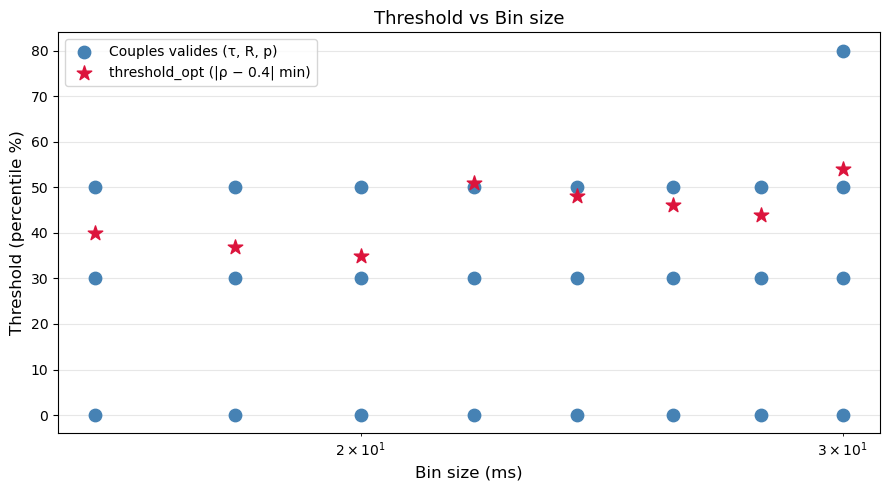

(<Figure size 900x500 with 1 Axes>,
 [(np.float64(0.016), np.int64(40)),
  (np.float64(0.018), np.int64(37)),
  (np.float64(0.02), np.int64(35)),
  (np.float64(0.022), np.int64(51)),
  (np.float64(0.024), np.int64(48)),
  (np.float64(0.026), np.int64(46)),
  (np.float64(0.028), np.int64(44)),
  (np.float64(0.03), np.int64(54))])

In [40]:
plot_threshold_vs_binsize(L, results, FR_cache, rho_target=0.4)# J'ai mis 0.4 au lieu de 0.2, car plus proches des valeurs de nos thresholds optimaux trouvés précédemment (30-50%) 

Choix : bin_size = 50ms, threshold = 45

Pour le perfectionnisme : étude du rapport bs/thr et bs²/thr par rapport à rho

In [8]:
def plot_rho_vs_bs_thr_ratios(FR_cache, bin_sizes=None, thresholds=None):
    """
    Plote rho en fonction de bs/thr et bs²/thr
    pour tous les couples (bin_size, threshold) de la grille.

    FR_cache : dict {bin_size (s): FR_array (Nx2)}
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if bin_sizes is None:
        bin_sizes  = np.arange(0.010, 0.075, 0.005)   # 10 à 70 ms, pas 5 ms
    if thresholds is None:
        thresholds = np.arange(10, 100, 10)             # 10 à 90, pas 10

    ratios_1  = []   # bs / thr
    ratios_2  = []   # bs² / thr
    rhos      = []
    labels    = []   # pour le hover-style print si besoin

    for bs in bin_sizes:
        # Chercher la clé la plus proche dans FR_cache
        available = np.array(list(FR_cache.keys()))
        closest   = available[np.argmin(np.abs(available - bs))]
        if abs(closest - bs) > 0.001:   # tolérance 1 ms
            continue
        rates = FR_cache[closest][:, 1]

        for thr in thresholds:
            seuil = np.percentile(rates, thr)
            rho   = np.mean(rates > seuil)

            ratios_1.append(bs / thr)
            ratios_2.append(bs**2 / thr)
            rhos.append(rho)
            labels.append((bs * 1000, thr, rho))

    ratios_1 = np.array(ratios_1)
    ratios_2 = np.array(ratios_2)
    rhos     = np.array(rhos)

    # Colormap sur rho
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('ρ (fraction bins actifs) vs ratios bin_size/threshold',
                 fontsize=13)

    for ax, ratios, xlabel in zip(
        axes,
        [ratios_1, ratios_2],
        ['bs / thr  (ms/%)', 'bs² / thr  (ms²/%)']
    ):
        sc = ax.scatter(ratios, rhos,
                        c=rhos, cmap='viridis',
                        s=60, alpha=0.8, zorder=3)
        ax.axhline(0.20, color='crimson', lw=1.5, ls='--',
                   label='ρ cible = 0.20')
        ax.axhline(0.10, color='orange',  lw=1,   ls=':',
                   label='ρ = 0.10')
        ax.axhline(0.40, color='orange',  lw=1,   ls=':',
                   label='ρ = 0.40')
        plt.colorbar(sc, ax=ax, label='ρ')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel('ρ = N_bins_actifs / N_bins_total', fontsize=11)
        ax.set_title(f'ρ vs {xlabel}', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print des couples où rho est le plus proche de 0.20
    print("\nCouples (bs, thr) avec ρ le plus proche de 0.20 :")
    sorted_idx = np.argsort(np.abs(rhos - 0.20))
    for i in sorted_idx[:10]:
        bs_ms, thr, rho = labels[i]
        print(f"  bin={bs_ms:.1f} ms | thr={thr:2.0f}% | "
              f"ρ={rho:.3f} | bs/thr={bs_ms/thr:.4f} | bs²/thr={bs_ms**2/thr:.4f}")

    return fig

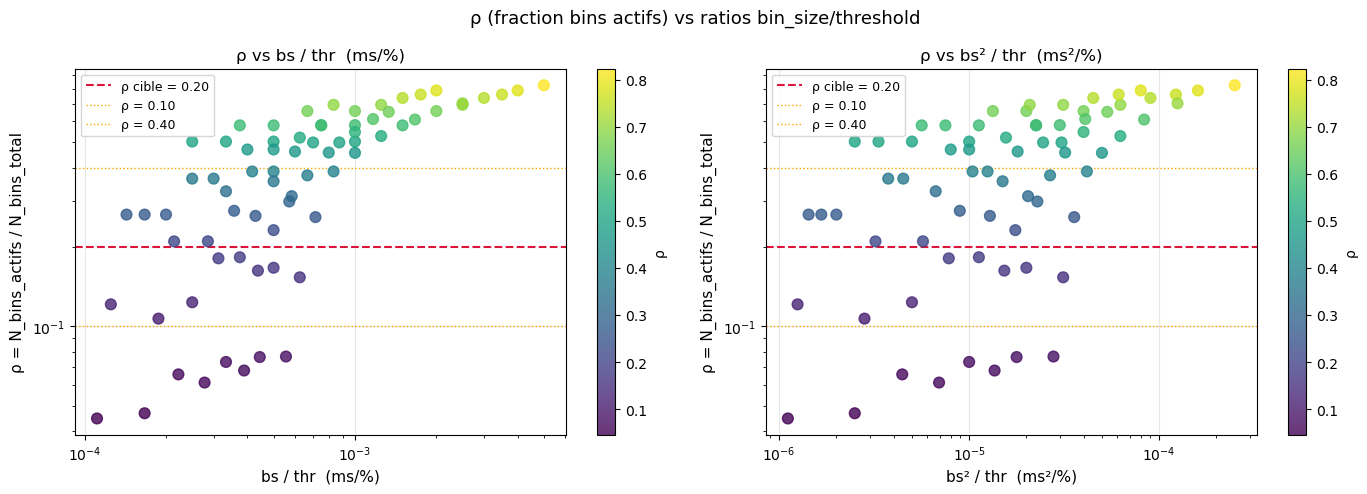


Couples (bs, thr) avec ρ le plus proche de 0.20 :
  bin=15.0 ms | thr=70% | ρ=0.210 | bs/thr=0.2143 | bs²/thr=3.2143
  bin=20.0 ms | thr=70% | ρ=0.210 | bs/thr=0.2857 | bs²/thr=5.7143
  bin=30.0 ms | thr=80% | ρ=0.183 | bs/thr=0.3750 | bs²/thr=11.2500
  bin=25.0 ms | thr=80% | ρ=0.181 | bs/thr=0.3125 | bs²/thr=7.8125
  bin=35.0 ms | thr=70% | ρ=0.232 | bs/thr=0.5000 | bs²/thr=17.5000
  bin=40.0 ms | thr=80% | ρ=0.167 | bs/thr=0.5000 | bs²/thr=20.0000
  bin=35.0 ms | thr=80% | ρ=0.163 | bs/thr=0.4375 | bs²/thr=15.3125
  bin=50.0 ms | thr=80% | ρ=0.154 | bs/thr=0.6250 | bs²/thr=31.2500
  bin=50.0 ms | thr=70% | ρ=0.260 | bs/thr=0.7143 | bs²/thr=35.7143
  bin=30.0 ms | thr=70% | ρ=0.263 | bs/thr=0.4286 | bs²/thr=12.8571


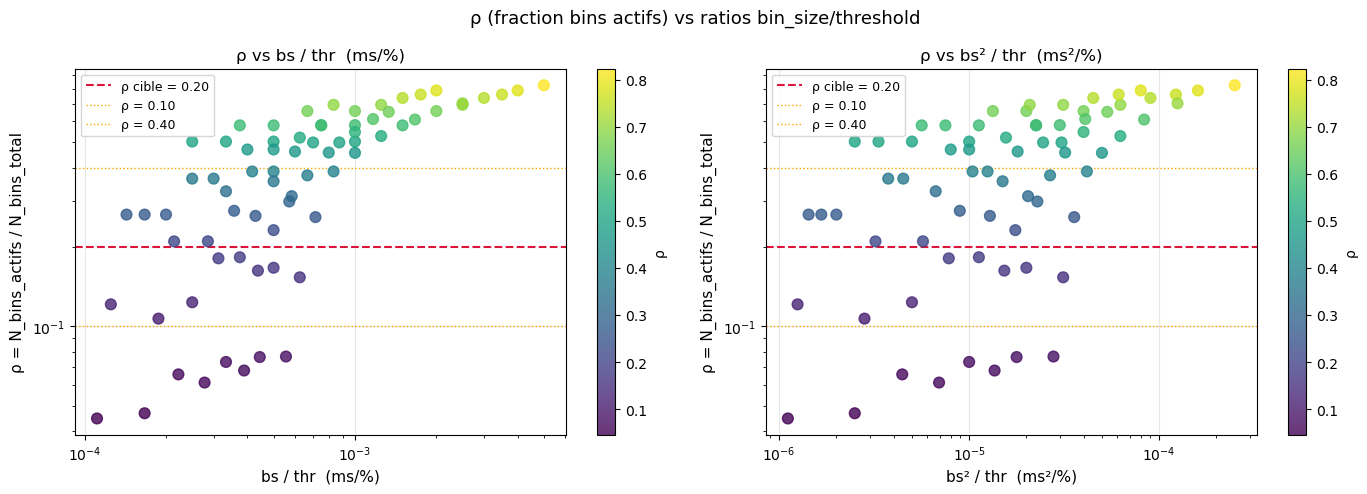

In [48]:
plot_rho_vs_bs_thr_ratios(FR_cache, bin_sizes=None, thresholds=None)

In [57]:
FR = R.firingRate(regs=["nr"], states='sws', window=0.05, step=1, shift=True)    
rates = FR[:, 1]
size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates,
        threshold=45,
        time_step=0.05,
        t0=FR[0, 0]
    )
print(intervals[:5], size[:5])
size, intervals, size_t = fma.analysis.avalanchesFromProfile(
        rates,
        threshold=45,
        time_step=0.05,
        t0=FR[0, 0]
    )
print(intervals[:5], size[:5])

[[5.68295411e-15 4.70000000e+00]
 [4.75000000e+00 6.70000000e+00]
 [6.75000000e+00 9.40000000e+00]
 [9.45000000e+00 9.60000000e+00]
 [9.65000000e+00 1.04000000e+01]] [585. 284. 301.   9.  78.]
[[5.68295411e-15 4.70000000e+00]
 [4.75000000e+00 6.70000000e+00]
 [6.75000000e+00 9.40000000e+00]
 [9.45000000e+00 9.60000000e+00]
 [9.65000000e+00 1.04000000e+01]] [585. 284. 301.   9.  78.]


BATCH

In [9]:
batch_file = "/mnt/hubel-data-103/Guillaume/Code/Python/batch_5rats.batch"
# get all sessions from batch file
sessions = fma.data.readBatchFile(batch_file)[0]

In [ ]:
import pickle, os

def run_session_criticality(session,
                             reg = "nr",
                             thresholds=None,
                             n_shuffles=10,
                             save_dir='/tmp/criticality_results'):
    """
    Fonction appelée par fma.data.runBatch pour chaque session.
    Calcule compute_grid et sauvegarde les résultats.
    """
    if thresholds is None:
        thresholds = [0, 30, 50, 80]

    os.makedirs(save_dir, exist_ok=True)

    # Nom de fichier basé sur la session
    session_id = os.path.splitext(os.path.basename(session))[0]
    save_path = os.path.join(save_dir, f'{session_id}_{reg}_criticality.pkl')
    
    if os.path.exists(save_path):
        print(f"[SKIP] {session_id} ({reg}) déjà calculé.")
        return

    try:
        R      = rg.data.Regions(session, ids=["nr", "pfc", "hpc"], states=['sws', 'rem'])
        spikes = R.spikes(regs=[reg], state='sws', shift=True)
        tmax   = spikes[:, 0].max()

        iei       = _estimate_iei(spikes, tmax)
        base_bins = np.arange(2, 52, 2) / 1000
        extra_bins= np.array([iei/2, iei, 0.087])
        all_bins  = np.unique(np.concatenate([base_bins, extra_bins]))
        all_bins  = all_bins[all_bins > 0]

        FR_cache = {}
        for bs in all_bins:
            FR_cache[bs] = R.firingRate(regs=[reg], states='sws',
                                        window=bs, step=1, shift=True)

        results = compute_grid(session, spikes, FR_cache,
                               all_bins, thresholds, tmax,
                               n_shuffles=n_shuffles)

        # Sauvegarder sans FR_cache (trop lourd) — juste results + méta
        out = dict(
            session   = session,
            session_id= session_id,
            all_bins  = all_bins,
            thresholds= thresholds,
            results   = results,
            n_spikes  = len(spikes),
            n_units   = len(np.unique(spikes[:, 1])),
            tmax      = tmax,
            iei_ms    = iei * 1000,
        )
        with open(save_path, 'wb') as f:
            pickle.dump(out, f)
        print(f"[OK] {session_id} ({reg}) → {save_path}")

    except Exception as e:
        print(f"[ERROR] {session_id} ({reg}) : {e}")

In [17]:
def aggregate_batch_results(save_dir='/tmp/criticality_results'):
    """
    Charge tous les fichiers .pkl du save_dir et extrait les métriques clés
    pour chaque (session, bin_size, threshold).

    Retourne un DataFrame avec une ligne par (session, bin_size, threshold).
    """
    import pandas as pd, glob

    files = sorted(glob.glob(os.path.join(save_dir, '*_criticality.pkl')))
    print(f"{len(files)} sessions trouvées.")

    rows = []
    for fpath in files:
        with open(fpath, 'rb') as f:
            data = pickle.load(f)

        sid      = data['session_id']
        all_bins = data['all_bins']
        results  = data['results']

        for thr in data['thresholds']:
            for bs in all_bins:
                m = results[thr][bs]

                tau      = m['tau']
                tau_sh   = m['tau_sh_mean']
                tau_std  = m['tau_sh_std']
                R        = m['R']
                p        = m['p']
                tau_dur  = m['tau_dur']
                tau_gamma= m['tau_gamma']
                ratio_exp= m['ratio_exp']
                n_tail   = m['n_tail_proportion']
                aval_rate= m['aval_rate']
                fit_range = m.get('fit_range', np.nan)
                fit_range_dur = m.get('fit_range_dur', np.nan)

                # Critères binaires
                tau_outside_shuffle = (
                    not any(np.isnan([tau, tau_sh, tau_std])) and
                    abs(tau - tau_sh) > 2 * tau_std
                )
                R_positive = (not np.isnan(R)) and R > 0
                p_sig      = (not np.isnan(p)) and p < 0.05
                n_tail_ok  = (not np.isnan(n_tail)) and n_tail > 0.1

                # Cohérence gamma : |ratio_exp - tau_gamma| < 0.3
                gamma_consistent = (
                    not any(np.isnan([ratio_exp, tau_gamma])) and
                    abs(ratio_exp - tau_gamma) < 0.3
                )

                # Score composite (nb de critères satisfaits sur 5)
                score = sum([tau_outside_shuffle, R_positive, p_sig,
                             n_tail_ok, gamma_consistent])

                rows.append(dict(
                    session          = sid,
                    bin_ms           = bs * 1000,
                    threshold        = thr,
                    tau              = tau,
                    tau_sh           = tau_sh,
                    tau_std          = tau_std,
                    tau_z            = (tau - tau_sh) / tau_std if tau_std and tau_std > 0 else np.nan,
                    R                = R,
                    p                = p,
                    tau_dur          = tau_dur,
                    tau_gamma        = tau_gamma,
                    ratio_exp        = ratio_exp,
                    n_tail           = n_tail,
                    aval_rate        = aval_rate,
                    rho              = aval_rate * bs,
                    tau_outside_sh   = tau_outside_shuffle,
                    R_positive       = R_positive,
                    p_sig            = p_sig,
                    n_tail_ok        = n_tail_ok,
                    gamma_consistent = gamma_consistent,
                    score            = score,
                    n_units          = data['n_units'],
                    tmax             = data['tmax'],
                    iei_ms           = data['iei_ms'],
                    fit_range        = fit_range,
                    fit_range_dur    = fit_range_dur
                ))

    return pd.DataFrame(rows)

In [15]:
def plot_batch_stats(df, thresholds_to_show=None):
    """
    df : DataFrame retourné par aggregate_batch_results()
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if thresholds_to_show is None:
        thresholds_to_show = sorted(df['threshold'].unique())

    bin_sizes = sorted(df['bin_ms'].unique())
    colors    = plt.cm.tab10(np.linspace(0, 1, len(thresholds_to_show)))

    # 
    # Figure 1 : critères binaires + τ + score + heatmap  (comme avant)
    # 
    fig1, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig1.suptitle('Batch  criticité NR (vue générale)', fontsize=14)

    # ── Plot 1 : fraction sessions valides par critère ───────────────────────
    ax = axes[0, 0]
    criteria    = ['tau_outside_sh', 'R_positive', 'p_sig',
                   'n_tail_ok', 'gamma_consistent']
    crit_colors = ['steelblue', 'darkgreen', 'orange', 'purple', 'crimson']
    for crit, col in zip(criteria, crit_colors):
        frac = [df[df['bin_ms'] == b][crit].mean() for b in bin_sizes]
        ax.plot(bin_sizes, frac, 'o-', color=col, lw=1.5, label=crit)
    ax.axhline(0.5, color='grey', lw=1, ls='--', label='50% sessions')
    ax.set_xscale('log'); ax.set_xlabel('Bin size (ms)')
    ax.set_ylabel('Fraction sessions')
    ax.set_title('Critères vs bin_size (tous thresholds)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # ── Plot 2 : τ moyen ± std inter-sessions ───────────────────────────────
    ax = axes[0, 1]
    ax.axhline(1.5, color='grey', lw=1, ls='--', label='τ théorique = 1.5')
    for thr, col in zip(thresholds_to_show, colors):
        sub      = df[df['threshold'] == thr]
        tau_mean = np.array([sub[sub['bin_ms'] == b]['tau'].mean() for b in bin_sizes])
        tau_std  = np.array([sub[sub['bin_ms'] == b]['tau'].std()  for b in bin_sizes])
        valid    = ~np.isnan(tau_mean)
        ax.fill_between(np.array(bin_sizes)[valid],
                        (tau_mean - tau_std)[valid],
                        (tau_mean + tau_std)[valid],
                        alpha=0.15, color=col)
        ax.plot(np.array(bin_sizes)[valid], tau_mean[valid],
                'o-', color=col, lw=1.5, label=f'thr={thr}%')
    ax.set_xscale('log'); ax.set_xlabel('Bin size (ms)')
    ax.set_ylabel('τ_size (mean ± std)')
    ax.set_title('τ moyen vs bin_size par threshold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── Plot 3 : score composite moyen ──────────────────────────────────────
    ax = axes[1, 0]
    for thr, col in zip(thresholds_to_show, colors):
        sub   = df[df['threshold'] == thr]
        score = [sub[sub['bin_ms'] == b]['score'].mean() for b in bin_sizes]
        ax.plot(bin_sizes, score, 'o-', color=col, lw=1.5, label=f'thr={thr}%')
    ax.axhline(4, color='grey', lw=1, ls='--', label='score ≥ 4/5')
    ax.set_xscale('log'); ax.set_xlabel('Bin size (ms)')
    ax.set_ylabel('Score composite moyen (05)')
    ax.set_title('Score composite vs bin_size')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── Plot 4 : heatmap score ───────────────────────────────────────────────
    ax = axes[1, 1]
    thrs_all = sorted(df['threshold'].unique())
    matrix   = np.array([
        [df[(df['bin_ms'] == b) & (df['threshold'] == t)]['score'].mean()
         for b in bin_sizes]
        for t in thrs_all
    ])
    im = ax.imshow(matrix, aspect='auto', cmap='viridis',
                   origin='lower', vmin=0, vmax=5)
    ax.set_xticks(range(len(bin_sizes)))
    ax.set_xticklabels([f'{b:.1f}' for b in bin_sizes], rotation=90, fontsize=6)
    ax.set_yticks(range(len(thrs_all)))
    ax.set_yticklabels([f'{t}%' for t in thrs_all])
    ax.set_xlabel('Bin size (ms)'); ax.set_ylabel('Threshold')
    ax.set_title('Heatmap score composite moyen')
    plt.colorbar(im, ax=ax, label='Score (05)')
    plt.tight_layout(); plt.show()

    # 
    # Figure 2 : xmax/xmin  +  R et p  +  relation de scaling
    # 
    fig2, axes2 = plt.subplots(1, 3, figsize=(21, 6))
    fig2.suptitle('Batch  métriques de qualité du fit', fontsize=14)

    # ── Plot 5 : xmax/xmin (mean ± std) ─────────────────────────────────────
    ax = axes2[0]
    ax.axhline(10, color='grey', lw=1, ls='--', label='xmax/xmin = 10 (référence)')
    for thr, col in zip(thresholds_to_show, colors):
        sub  = df[df['threshold'] == thr]
        # fit_range est déjà xmax/xmin dans le df si tu l'as stocké,
        # sinon on peut le recalculer depuis n_tail × autres métriques.
        # Ici on suppose que tu as une colonne 'fit_range' dans le df.
        # Si pas encore présente, ajouter dans aggregate_batch_results :
        #   'fit_range': m.get('fit_range', np.nan)
        m_arr = np.array([sub[sub['bin_ms'] == b]['fit_range'].mean()
                          for b in bin_sizes])
        s_arr = np.array([sub[sub['bin_ms'] == b]['fit_range'].std()
                          for b in bin_sizes])
        valid = ~np.isnan(m_arr)
        ax.fill_between(np.array(bin_sizes)[valid],
                        (m_arr - s_arr)[valid],
                        (m_arr + s_arr)[valid],
                        alpha=0.15, color=col)
        ax.plot(np.array(bin_sizes)[valid], m_arr[valid],
                'o-', color=col, lw=1.5, label=f'thr={thr}%')
    ax.set_xscale('log'); ax.set_xlabel('Bin size (ms)')
    ax.set_ylabel('xmax / xmin (mean ± std)')
    ax.set_title('Plage du fit power law (sizes)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── Plot 6 : R (mean ± std) et p (mean) ─────────────────────────────────
    ax   = axes2[1]
    ax.axhline(0, color='grey', lw=1, ls='--', label='R = 0')
    ax6b = ax.twinx()
    ax6b.axhline(0.05, color='orange', lw=0.8, ls=':', label='p = 0.05')

    for thr, col in zip(thresholds_to_show, colors):
        sub   = df[df['threshold'] == thr]
        R_m   = np.array([sub[sub['bin_ms'] == b]['R'].mean()   for b in bin_sizes])
        R_s   = np.array([sub[sub['bin_ms'] == b]['R'].std()    for b in bin_sizes])
        p_m   = np.array([sub[sub['bin_ms'] == b]['p'].mean()   for b in bin_sizes])
        valid = ~np.isnan(R_m)
        ax.fill_between(np.array(bin_sizes)[valid],
                        (R_m - R_s)[valid], (R_m + R_s)[valid],
                        alpha=0.15, color=col)
        ax.plot(np.array(bin_sizes)[valid], R_m[valid],
                'o-', color=col, lw=1.5, label=f'R thr={thr}%')
        valid_p = ~np.isnan(p_m)
        ax6b.plot(np.array(bin_sizes)[valid_p], p_m[valid_p],
                  's--', color=col, lw=1, alpha=0.6)

    ax.set_xscale('log'); ax.set_xlabel('Bin size (ms)')
    ax.set_ylabel('R  LR ratio (mean ± std)', color='darkgreen')
    ax.tick_params(axis='y', labelcolor='darkgreen')
    ax6b.set_ylabel('p-value moyenne', color='orange')
    ax6b.tick_params(axis='y', labelcolor='orange')
    ax.set_title('R et p-value vs bin_size')
    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax6b.get_legend_handles_labels()
    ax.legend(lines1+lines2, l1+l2, fontsize=7)
    ax.grid(True, alpha=0.3)

    # ── Plot 7 : relation de scaling ─────────────────────────────────────────
    # gamma_theorique = ratio_exp = (tau_dur-1)/(tau_size-1)
    # gamma_scaling   = tau_gamma  (fit log-log <s>(T))
    ax = axes2[2]
    ax.axhline(2.0, color='grey', lw=1, ls='--', label='γ théorique mean-field = 2')

    for thr, col in zip(thresholds_to_show, colors):
        sub = df[df['threshold'] == thr]

        # gamma_theorique = ratio_exp
        gt_m = np.array([sub[sub['bin_ms'] == b]['ratio_exp'].mean() for b in bin_sizes])
        gt_s = np.array([sub[sub['bin_ms'] == b]['ratio_exp'].std()  for b in bin_sizes])
        valid_gt = ~np.isnan(gt_m)
        ax.fill_between(np.array(bin_sizes)[valid_gt],
                        (gt_m - gt_s)[valid_gt], (gt_m + gt_s)[valid_gt],
                        alpha=0.10, color=col)
        ax.plot(np.array(bin_sizes)[valid_gt], gt_m[valid_gt],
                'o-', color=col, lw=2,
                label=f'γ_théo thr={thr}%')

        # gamma_scaling = tau_gamma
        gs_m = np.array([sub[sub['bin_ms'] == b]['tau_gamma'].mean() for b in bin_sizes])
        gs_s = np.array([sub[sub['bin_ms'] == b]['tau_gamma'].std()  for b in bin_sizes])
        valid_gs = ~np.isnan(gs_m)
        ax.fill_between(np.array(bin_sizes)[valid_gs],
                        (gs_m - gs_s)[valid_gs], (gs_m + gs_s)[valid_gs],
                        alpha=0.10, color=col)
        ax.plot(np.array(bin_sizes)[valid_gs], gs_m[valid_gs],
                's--', color=col, lw=1.5,
                label=f'γ_scaling thr={thr}%')

    ax.set_xscale('log'); ax.set_xlabel('Bin size (ms)')
    ax.set_ylabel('γ (mean ± std inter-sessions)')
    ax.set_title('Relation de scaling : γ_théo vs γ_scaling')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    return fig1, fig2

In [13]:
# ── Lancement batch ──────────────────────────────────────────────────────────
fma.data.runBatch(batch_file, run_session_criticality, ignore_args=True)


Starting Batch, 2026-06-18 16:42:38.519150 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml, 1 out of 60
[SKIP] Rat003_20231212 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231213/Rat003_20231213.xml, 2 out of 60
[SKIP] Rat003_20231213 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml, 3 out of 60
[SKIP] Rat003_20231214 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml, 4 out of 60
[SKIP] Rat003_20231215 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml, 5 out of 60
[SKIP] Rat003_20231218 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml, 6 out of 60
[SKIP] Rat003_20231219 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml, 7 out of 60
[SKIP] Rat003_20231221 déjà calculé.

Batch progress: /mnt/hubel-dat

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

55 sessions trouvées.


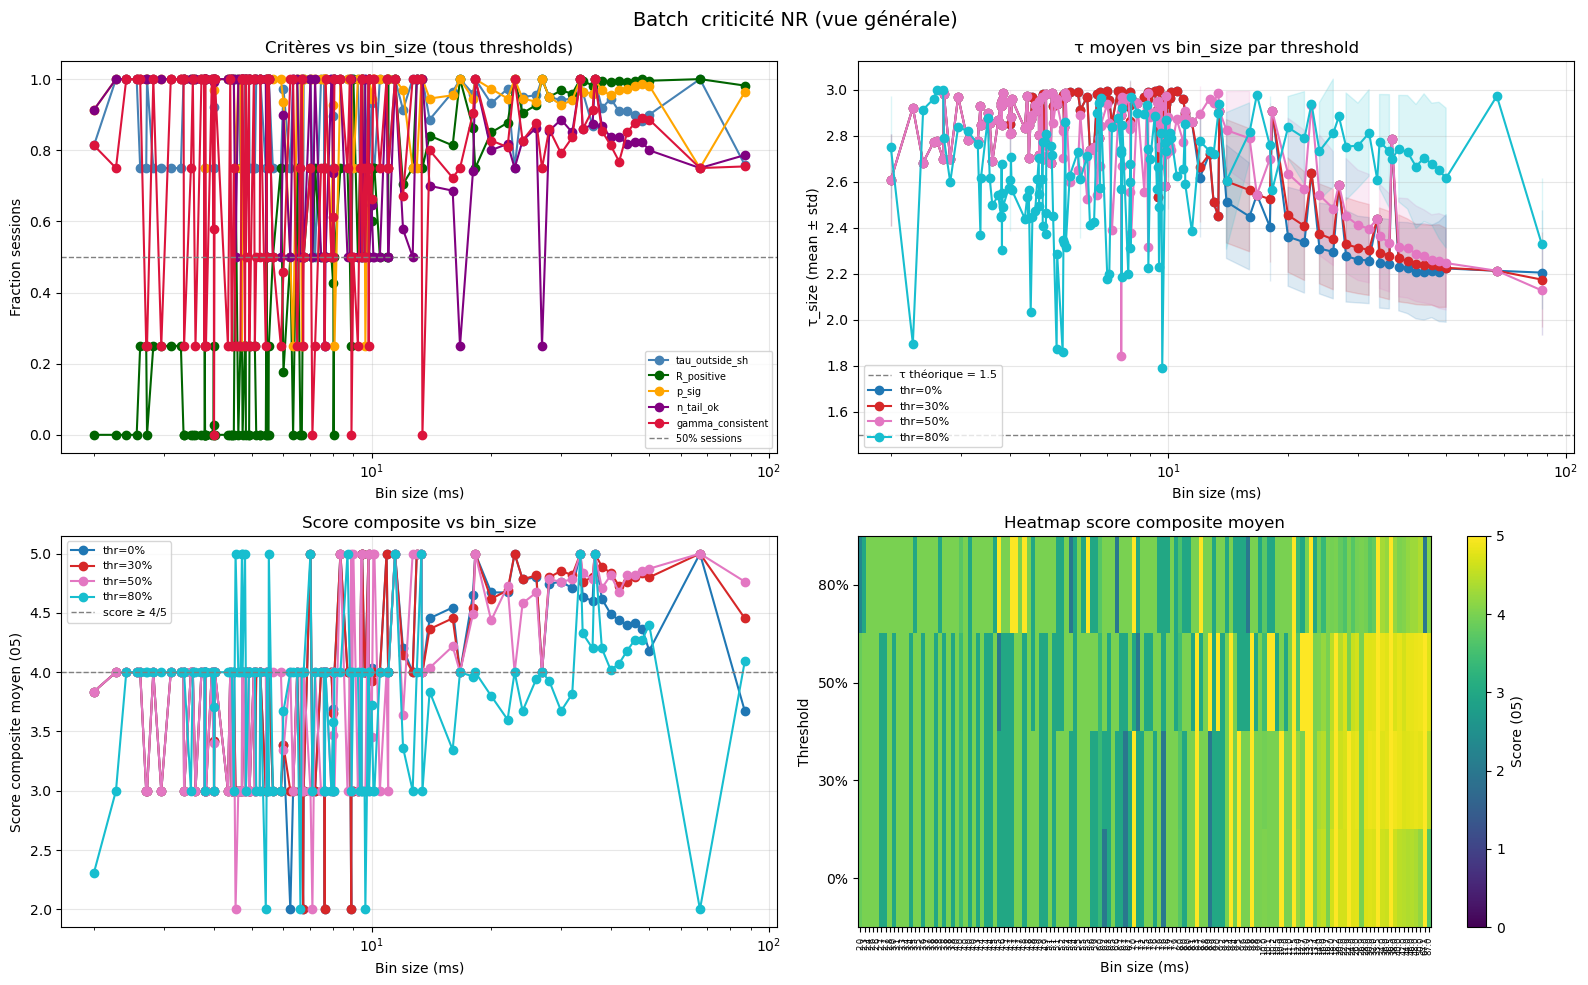

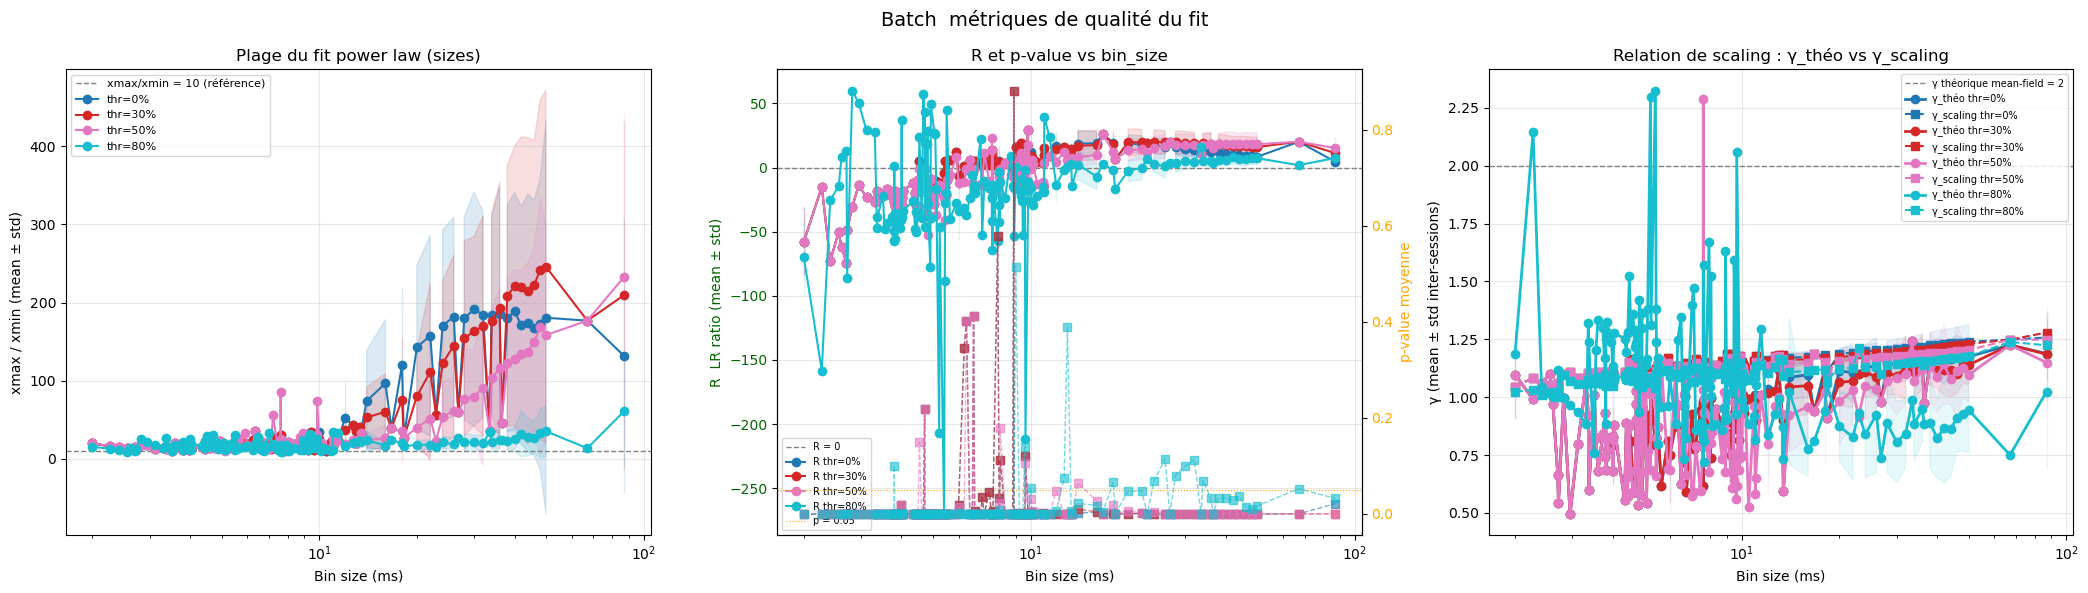

        bin_ms  threshold  score
465  22.912496         30    5.0
464  22.912496          0    5.0
495  33.547623         80    5.0
159   4.801678         80    5.0
147   4.716435         80    5.0
492  33.547623          0    5.0
493  33.547623         30    5.0
454  18.238514         50    5.0
372   9.824847          0    5.0
342   8.998810         50    5.0


In [18]:
# ── Agrégation et visualisation ──────────────────────────────────────────────
df = aggregate_batch_results(save_dir='/tmp/criticality_results')
fig = plot_batch_stats(df)

# ── Accès direct aux meilleures combinaisons ─────────────────────────────────
best = (df.groupby(['bin_ms', 'threshold'])['score']
          .mean()
          .reset_index()
          .sort_values('score', ascending=False))
print(best.head(10))

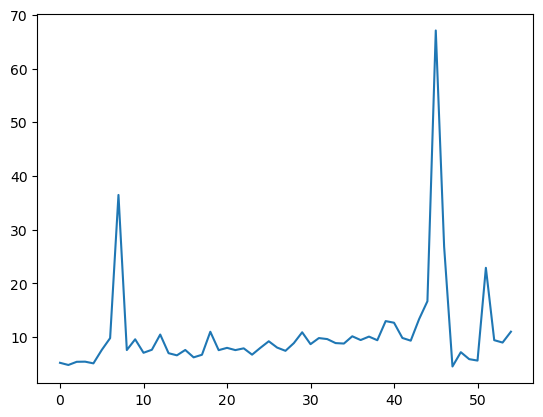

In [48]:
plt.plot(df['iei_ms'].unique())

In [49]:
def plot_iei_per_session(df):
    """
    Plote l'IEI moyen (ms) pour chaque session du batch.
    df doit contenir les colonnes 'session' et 'iei_ms'.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Une valeur d'IEI par session (indépendant du bin/threshold)
    iei_per_session = (df.groupby('session')['iei_ms']
                         .first()
                         .reset_index()
                         .sort_values('iei_ms'))

    sessions   = iei_per_session['session'].values
    iei_values = iei_per_session['iei_ms'].values

    # Labels courts pour l'affichage
    labels = [s.split('/')[-1].replace('.xml', '') for s in sessions]

    fig, ax = plt.subplots(figsize=(max(8, len(sessions) * 0.6), 5))

    bars = ax.bar(range(len(sessions)), iei_values,
                  color='steelblue', alpha=0.8, edgecolor='white')

    # Valeur au-dessus de chaque barre
    for i, (bar, val) in enumerate(zip(bars, iei_values)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02 * iei_values.max(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    # Ligne médiane
    median_iei = np.median(iei_values)
    ax.axhline(median_iei, color='crimson', lw=1.5, ls='--',
               label=f'Médiane = {median_iei:.2f} ms')

    ax.set_xticks(range(len(sessions)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Session', fontsize=12)
    ax.set_ylabel('IEI population moyen (ms)', fontsize=12)
    ax.set_title('IEI moyen par session', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Print résumé
    print(f"\nIEI moyen sur le batch : {iei_values.mean():.2f} ± {iei_values.std():.2f} ms")
    print(f"Min : {iei_values.min():.2f} ms ({labels[np.argmin(iei_values)]})")
    print(f"Max : {iei_values.max():.2f} ms ({labels[np.argmax(iei_values)]})")

    return fig

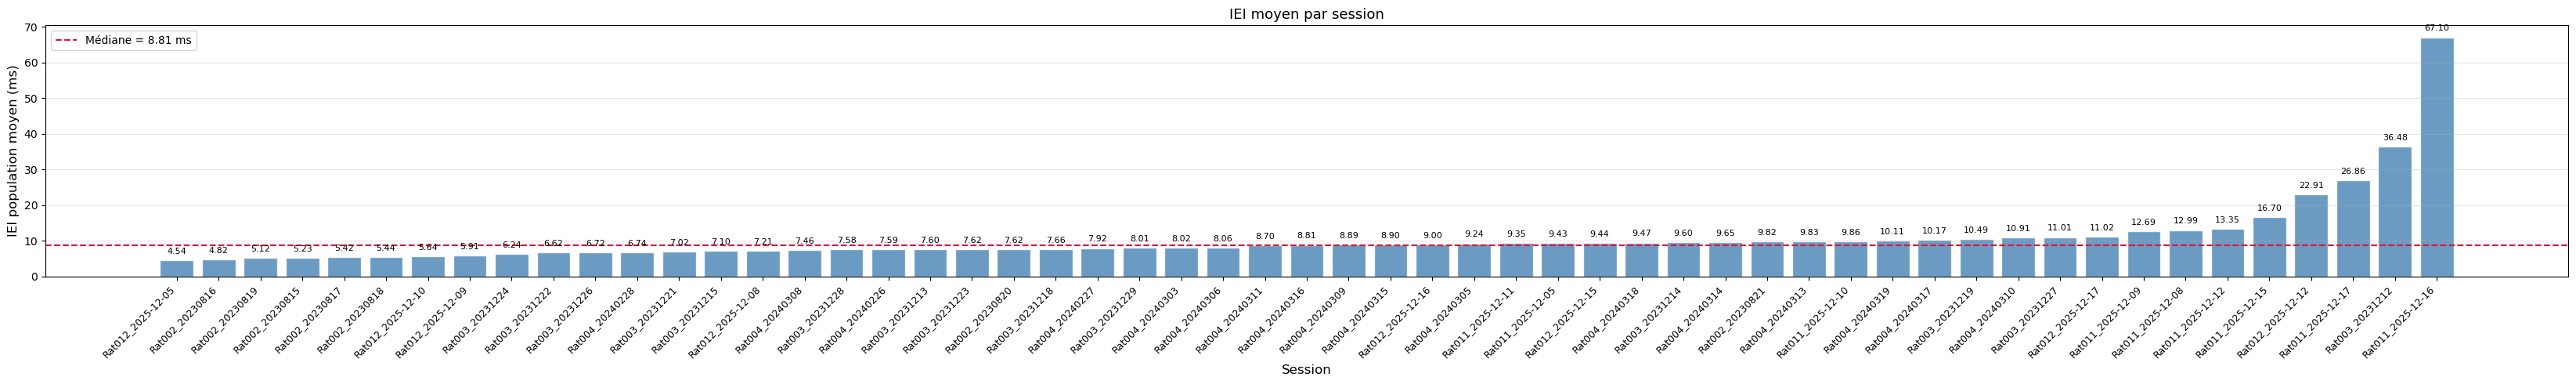


IEI moyen sur le batch : 10.69 ± 9.32 ms
Min : 4.54 ms (Rat012_2025-12-05)
Max : 67.10 ms (Rat011_2025-12-16)


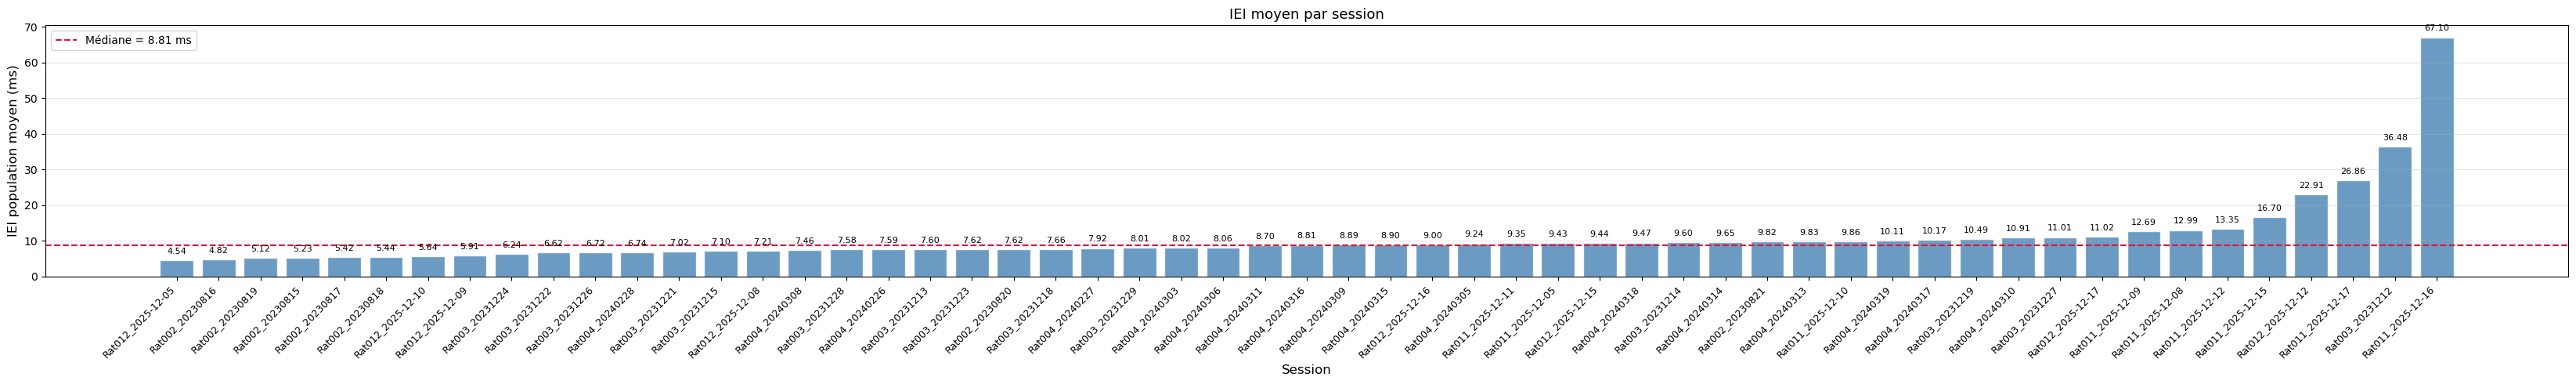

In [50]:
plot_iei_per_session(df)

In [68]:
def plot_dcc_per_session(results_dict, thresholds,
                          iei_dict=None, reg_colors=None):
    import matplotlib.pyplot as plt
    import numpy as np

    if reg_colors is None:
        reg_colors = {'nr': 'steelblue', 'pfc': 'darkorange', 'hpc': 'crimson'}

    fig, ax = plt.subplots(figsize=(11, 5))

    all_bs_ms_global = []

    for reg, results in results_dict.items():
        col = reg_colors.get(reg, 'grey')

        # Clés réelles du results pour cette région
        all_bins_reg = np.array(sorted(results[thresholds[0]].keys()))
        bs_ms_reg    = all_bins_reg * 1000
        all_bs_ms_global.extend(bs_ms_reg.tolist())

        #print(f"  Région {reg.upper()} : {all_bins_reg} bin_sizes ")

        dcc_per_bin = []
        for bs in all_bins_reg:
            dcc_vals = []
            for thr in thresholds:
                m  = results[thr][bs]
                re = m['ratio_exp']
                tg = m['tau_gamma']
                if np.isnan(re) or np.isnan(tg):
                    print(f"⚠️  DCC NaN pour {reg} | bin={bs*1000:.2f} ms | thr={thr}% : "
                          f"ratio_exp={re}, tau_gamma={tg}")
                if not any(np.isnan([re, tg])):
                    dcc_vals.append(abs(re - tg))
            dcc_per_bin.append(np.mean(dcc_vals) if dcc_vals else np.nan)

        dcc_arr = np.array(dcc_per_bin)
        valid   = ~np.isnan(dcc_arr)
        ax.plot(bs_ms_reg[valid], dcc_arr[valid],
                'o-', color=col, lw=2, label=reg.upper())

    # Axe x commun
    all_bs_ms_global = np.array(sorted(set(all_bs_ms_global)))
    bs_pos = all_bs_ms_global[all_bs_ms_global > 0]
    ax.set_xscale('log')
    ax.set_xlim(bs_pos.min(), bs_pos.max())

    # IEI sur axe x du dessus
    if iei_dict is not None:
        ax2 = ax.twiny()
        ax2.set_xscale('log')
        ax2.set_xlim(bs_pos.min(), bs_pos.max())
        ax2.set_xticks(list(iei_dict.values()))
        ax2.set_xticklabels([f'IEI_{k}\n{v:.2f} ms'
                              for k, v in iei_dict.items()], fontsize=8)
        for reg, iei_val in iei_dict.items():
            col = reg_colors.get(reg, 'grey')
            ax.axvline(iei_val, color=col, lw=1.5, ls='--', alpha=0.4)

    ax.axhline(0, color='grey', lw=1, ls='--', label='DCC=0')
    ax.set_xlabel('Bin size (ms)', fontsize=12)
    ax.set_ylabel('DCC = |γ_théo − γ_scaling|', fontsize=12)
    ax.set_title('Distance from Criticality par région', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

In [67]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R       = rg.data.Regions(session, ids=["nr","pfc","hpc"], states=['sws','rem'])

thresholds = [30] 

results_by_reg = {}
iei_by_reg     = {}

for reg in ['nr', 'pfc', 'hpc']:
    spikes = R.spikes(regs=[reg], state='sws', shift=True)
    tmax   = spikes[:, 0].max()
    iei    = _estimate_iei(spikes, tmax)
    iei_by_reg[reg] = iei * 1000

    #base_bins = np.arange(2, 52, 2) / 1000
    base_bins = np.arange(1, 80, 1) / 1000
    extra_bins= np.array([iei/2, iei, 0.087])
    all_bins  = np.unique(np.concatenate([base_bins, extra_bins]))
    all_bins  = all_bins[all_bins > 0]

    FR_cache = {bs: R.firingRate(regs=[reg], states='sws', window=bs, step=1, shift=True)
                for bs in all_bins}

    results_by_reg[reg] = compute_grid(session, spikes, FR_cache,
                                       all_bins, thresholds, tmax,
                                       n_shuffles=10)


  FR totale population : 95.3 Hz
  IEI population       : 10.491 ms

── bin=1.00 ms ──
  thr=30% | N=483609 | τ=3.000 | τ_sh=3.000±0.000 | R=-150.17 p=0.000 | aval_rate=92.0371| n_tail_prop=1.000 | tau_dur=nan | tau_gamma=0.996 | ratio_exp=nan

── bin=2.00 ms ──
  thr=30% | N=362275 | τ=2.495 | τ_sh=2.688±0.002 | R=-57.60 p=0.000 | aval_rate=87.6292| n_tail_prop=1.000 | tau_dur=2.584 | tau_gamma=1.035 | ratio_exp=1.060

── bin=3.00 ms ──
  thr=30% | N=274849 | τ=2.675 | τ_sh=2.322±0.002 | R=-35.09 p=0.000 | aval_rate=81.5100| n_tail_prop=0.447 | tau_dur=2.205 | tau_gamma=1.057 | ratio_exp=0.719

── bin=4.00 ms ──
  thr=30% | N=220648 | τ=2.756 | τ_sh=2.843±0.003 | R=-29.55 p=0.000 | aval_rate=74.9966| n_tail_prop=0.321 | tau_dur=2.664 | tau_gamma=1.077 | ratio_exp=0.948

── bin=5.00 ms ──
  thr=30% | N=182233 | τ=2.766 | τ_sh=2.619±0.003 | R=-23.62 p=0.000 | aval_rate=69.2943| n_tail_prop=0.269 | tau_dur=2.068 | tau_gamma=1.083 | ratio_exp=0.605

── bin=5.25 ms ──
  thr=30% | N=174346 

⚠️  DCC NaN pour nr | bin=1.00 ms | thr=30% : ratio_exp=nan, tau_gamma=0.9962474137194136
⚠️  DCC NaN pour pfc | bin=1.00 ms | thr=30% : ratio_exp=nan, tau_gamma=0.995236213572302


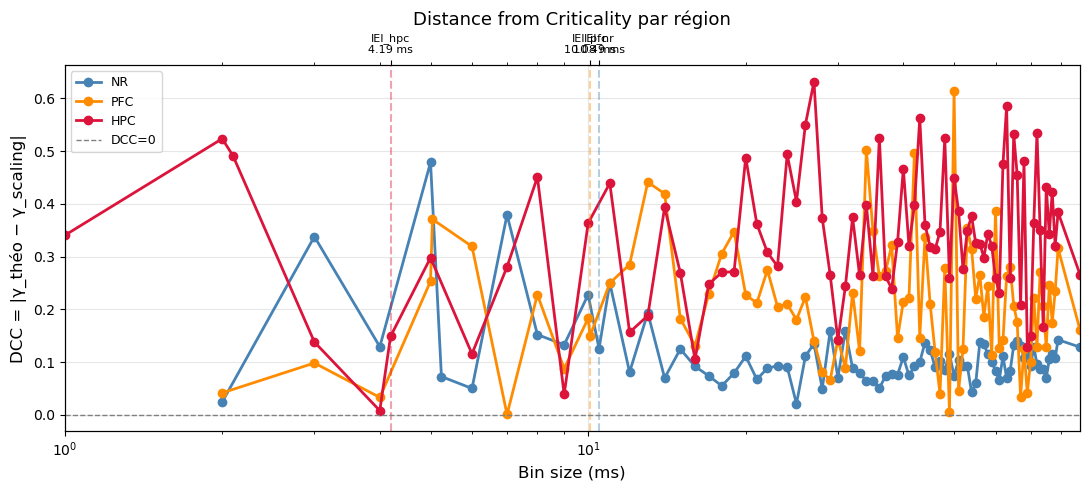

In [69]:
fig = plot_dcc_per_session(results_by_reg, thresholds, iei_dict=iei_by_reg)

In [70]:
# Un wrapper par région — ignore_args=True permet à runBatch 
# de passer juste la session sans autres arguments

def run_session_criticality_nr(session):
    run_session_criticality(session, reg="nr",
                             save_dir='/tmp/criticality_results')

def run_session_criticality_pfc(session):
    run_session_criticality(session, reg="pfc",
                             save_dir='/tmp/criticality_results')

def run_session_criticality_hpc(session):
    run_session_criticality(session, reg="hpc",
                             save_dir='/tmp/criticality_results')
    
fma.data.runBatch(batch_file, run_session_criticality_nr,  ignore_args=True)
fma.data.runBatch(batch_file, run_session_criticality_pfc, ignore_args=True)
fma.data.runBatch(batch_file, run_session_criticality_hpc, ignore_args=True)


Starting Batch, 2026-07-01 16:51:31.576213 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml, 1 out of 60
[SKIP] Rat003_20231212 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231213/Rat003_20231213.xml, 2 out of 60
[SKIP] Rat003_20231213 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml, 3 out of 60
[SKIP] Rat003_20231214 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml, 4 out of 60
[SKIP] Rat003_20231215 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml, 5 out of 60
[SKIP] Rat003_20231218 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml, 6 out of 60
[SKIP] Rat003_20231219 déjà calculé.

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml, 7 out of 60
[SKIP] Rat003_20231221 déjà calculé.

Batch progress: /mnt/hubel-dat

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [74]:
import os, glob
files = glob.glob('/tmp/criticality_results/*.pkl')
for f in sorted(files)[:5]:
    print(os.path.basename(f))

Rat002_20230815_criticality.pkl
Rat002_20230816_criticality.pkl
Rat002_20230817_criticality.pkl
Rat002_20230818_criticality.pkl
Rat002_20230819_criticality.pkl


In [71]:
def plot_dcc_batch(save_dir='/tmp/criticality_results',
                   regs=('nr','pfc','hpc'), reg_colors=None):
    """
    Charge tous les pickles, calcule DCC moyen ± std inter-sessions
    pour chaque région et chaque bin_size.
    """
    import glob, pickle, matplotlib.pyplot as plt, numpy as np

    if reg_colors is None:
        reg_colors = {'nr':'steelblue','pfc':'darkorange','hpc':'crimson'}

    # Charger les données par région
    data_by_reg = {reg: [] for reg in regs}
    for reg in regs:
        for fpath in sorted(glob.glob(
                os.path.join(save_dir, f'*_{reg}_criticality.pkl'))):
            with open(fpath, 'rb') as f:
                data_by_reg[reg].append(pickle.load(f))

    # Grille de bins commune = union des grilles des sessions
    all_bins_set = set()
    for reg in regs:
        for d in data_by_reg[reg]:
            all_bins_set.update(d['all_bins'].tolist())
    all_bins = np.array(sorted(all_bins_set))
    bs_ms    = all_bins * 1000
    bs_lim   = (bs_ms[bs_ms>0].min(), bs_ms[bs_ms>0].max())

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_xscale('log'); ax.set_xlim(bs_lim)

    for reg in regs:
        col      = reg_colors.get(reg, 'grey')
        sessions = data_by_reg[reg]
        if not sessions:
            continue

        # DCC par session et par bin_size
        dcc_matrix = []
        iei_vals   = []

        for d in sessions:
            iei_vals.append(d['iei_ms'])
            row = []
            for bs in all_bins:
                if bs not in d['results'][d['thresholds'][0]]:
                    row.append(np.nan); continue
                dcc_vals = []
                for thr in d['thresholds']:
                    m  = d['results'][thr][bs]
                    re = m['ratio_exp']; tg = m['tau_gamma']
                    if not any(np.isnan([re, tg])):
                        dcc_vals.append(abs(re - tg))
                row.append(np.mean(dcc_vals) if dcc_vals else np.nan)
            dcc_matrix.append(row)

        dcc_matrix = np.array(dcc_matrix)           # (n_sessions, n_bins)
        dcc_mean   = np.nanmean(dcc_matrix, axis=0)
        dcc_std    = np.nanstd(dcc_matrix,  axis=0)
        valid      = ~np.isnan(dcc_mean)

        ax.fill_between(bs_ms[valid],
                        (dcc_mean - dcc_std)[valid],
                        (dcc_mean + dcc_std)[valid],
                        alpha=0.15, color=col)
        ax.plot(bs_ms[valid], dcc_mean[valid],
                'o-', color=col, lw=2, label=reg.upper())

        # IEI moyen de la région sur l'axe x
        iei_mean = np.mean(iei_vals)
        ax.axvline(iei_mean, color=col, lw=1.5, ls='--', alpha=0.5)
        ax.text(iei_mean, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 1,
                f'IEI_{reg}\n{iei_mean:.1f}ms',
                color=col, fontsize=7, ha='center', va='top')

    ax.axhline(0, color='grey', lw=1, ls='--', label='DCC=0')
    ax.set_xlabel('Bin size (ms)', fontsize=12)
    ax.set_ylabel('DCC = |γ_théo − γ_scaling| (mean ± std)', fontsize=12)
    ax.set_title('Distance from Criticality — batch multi-régions', fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return fig

In [72]:
plot_dcc_batch(save_dir='/tmp/criticality_results',
                   regs=('nr','pfc','hpc'), reg_colors=None)

ValueError: zero-size array to reduction operation minimum which has no identity